In [1]:
# =============================================================================
# CELL 1: CONFIGURATION, FORMULA CONSTANTS, AND BASELINES
# =============================================================================
# RAGU V3 formula with UL-dependent scoring:
#   - GL: (1-LM) * UL/0.027, where UL = 0.9 - (MS-125)*0.027 - (72-term)/240
#   - Recovery: UL * F * R * 100
#   - LTV: LTV_COEF * (baseline - actual), blended from coupling + GL studies
#   - APR: (baseline - actual)/0.01 * APR_MULT (unchanged from GL study)

# --- Date Range ---
START_DATE = '2020-01-01'
END_DATE = None

# --- Query Control ---
run_every_query = True

# --- LOBs ---
LOBS = ['AN', 'FRN', 'STG', 'FLD', 'ENT', 'KMX']

# --- Rollup Groups ---
ROLLUP_GROUPS = {
    'Franchise Independent': ['AN', 'FLD', 'FRN', 'STG'],
    'nonKMX': ['AN', 'FRN', 'STG', 'FLD', 'ENT'],
    'POS': ['AN', 'FRN', 'STG', 'FLD', 'ENT', 'KMX'],
}

# --- Per-LOB Baselines ---
BASELINES = {
    'AN':  {'ltv': 1.94, 'apr': 0.25},
    'FRN': {'ltv': 1.94, 'apr': 0.25},
    'STG': {'ltv': 1.94, 'apr': 0.25},
    'FLD': {'ltv': 1.45, 'apr': 0.235},
    'ENT': {'ltv': 1.45, 'apr': 0.235},
    'KMX': {'ltv': 1.59, 'apr': 0.25},
}

# --- V3 Formula Parameters (UL-based, data-driven) ---
# Unit Loss: UL = 0.9 - (MS - 125)*0.027 - (72 - term)/240
UL_TO_MS = 0.027
UL_INTERCEPT = 0.9
UL_MS_CENTER = 125
UL_TERM_CENTER = 72
UL_TERM_DENOM = 240
RECOVERY_TO_SCORE = 100  # 1 RAGU pt = 1 ppt CNL

APR_MULT = 0.8223      # OLS-optimal: |coef_APR|/100 / |coef_ms|
FIND_RATE = 0.75       # Empirically validated (regression coef on R = 0.7437)
LTV_COEF = 1.1         # Blended: beta_ltv * F * GL_mult = 0.09 * 0.75 * 16.5

# --- Sensitivity Scenarios (LOO min/max from vintage_sensitivity_analysis) ---
SCENARIOS = {
    'Base':     {'apr_mult': 0.8223, 'ltv_coef': 1.1,  'find_rate': 0.75},
    'APR High': {'apr_mult': 0.95,   'ltv_coef': 1.1,  'find_rate': 0.75},
    'APR Low':  {'apr_mult': 0.78,   'ltv_coef': 1.1,  'find_rate': 0.75},
    'LTV High': {'apr_mult': 0.8223, 'ltv_coef': 1.35, 'find_rate': 0.75},
    'LTV Low':  {'apr_mult': 0.8223, 'ltv_coef': 0.81, 'find_rate': 0.75},
    'F High':   {'apr_mult': 0.8223, 'ltv_coef': 1.1,  'find_rate': 0.81},
    'F Low':    {'apr_mult': 0.8223, 'ltv_coef': 1.1,  'find_rate': 0.60},
}

# --- KMX Rescaling ---
KMX_BPS_PER_POINT = 0.65
KMX_MS_OFFSET = 50

# --- MMI Vintage Adjustment ---
MMI_ENABLED = True     # Toggle MMI market adjustment on vintage-level panels
MMI_LAG_MONTHS = 24    # Average months to repossession
MMI_COEF = None        # Set after running mmi_vintage_adjustment_study.ipynb (auto-derived below)

In [2]:
# =============================================================================
# CELL 2: IMPORTS AND DERIVED CONFIGURATION
# =============================================================================
import pandas as pd
import numpy as np
import pyodbc
import pickle
import warnings
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
from tqdm.notebook import tqdm

tqdm.pandas()
pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 100)

start_date = pd.Timestamp(START_DATE)
end_date = pd.Timestamp(END_DATE) if END_DATE else pd.Timestamp.today().normalize()
min_date_sql = f"'{START_DATE}'"

g_start_period = start_date.to_period('M')
g_end_period = end_date.to_period('M')

print(f"Period range: {g_start_period} to {g_end_period}")
print(f"SQL min_date: {min_date_sql}")

Period range: 2020-01 to 2026-08
SQL min_date: '2020-01-01'


In [3]:
# =============================================================================
# CELL 3: RAGU V3 FORMULA DEFINITIONS
# =============================================================================

def compute_unit_loss(model_score, con_term):
    """V2-style unit loss: score and term dependent.
    UL = 0.9 - (MS - 125)*0.027 - (72 - term)/240"""
    return UL_INTERCEPT - (model_score - UL_MS_CENTER) * UL_TO_MS - (UL_TERM_CENTER - con_term) / UL_TERM_DENOM


def compute_gross_loss_impact(loss_multiplier, unit_loss):
    """GL impact: (1-LM) * UL / 0.027. UL replaces constant GL_MULT."""
    return (1 - loss_multiplier) * unit_loss / UL_TO_MS


def compute_recovery_impact(recovery_multiplier, unit_loss, find_rate=FIND_RATE):
    """Recovery impact: UL * F * R * 100.
    Converts recovery fraction to score points (1 pt = 1 ppt CNL)."""
    return unit_loss * find_rate * recovery_multiplier * RECOVERY_TO_SCORE


def compute_ltv_impact(baseline_ltv, actual_ltv, ltv_coef=LTV_COEF):
    """LTV impact: single blended coefficient on (baseline - actual).
    LTV_COEF ~1.1 = beta_ltv * F * GL_mult from coupling + GL studies."""
    return ltv_coef * (baseline_ltv - actual_ltv)


def compute_apr_impact(baseline_apr, actual_apr, apr_mult=APR_MULT):
    """APR impact: per 1% deviation from baseline.
    OLS-optimal: coef_APR/100 / coef_ms = 0.8223."""
    return (baseline_apr - actual_apr) / 0.01 * apr_mult


def rescale_kmx(value, bps_per_point=KMX_BPS_PER_POINT, ms_offset=KMX_MS_OFFSET,
                is_model_score=False):
    """Rescale KMX from 65bps/pt to 100bps/pt space."""
    scaled = value * bps_per_point
    if is_model_score:
        scaled += ms_offset
    return scaled

In [4]:
# =============================================================================
# CELL 4: UTILITY FUNCTIONS
# =============================================================================

def run_sql(filename, sub_list=None, connection=None, filename_is_query=False,
            chunksize=200_000):
    if sub_list is None:
        sub_list = []
    if filename_is_query:
        query = filename
    else:
        with open(filename, 'r') as file:
            query = file.read()
    for text, var in sub_list:
        query = query.replace(text, var)

    def _read(conn):
        warnings.filterwarnings("ignore", category=UserWarning)
        chunks = pd.read_sql_query(sql=query, con=conn, chunksize=chunksize)
        df = pd.concat(chunks, ignore_index=True)
        warnings.filterwarnings("default", category=UserWarning)
        return df

    if connection is None:
        with pyodbc.connect("DSN=Redshift_prod_new") as conn:
            return _read(conn)
    else:
        return _read(connection)


def store_pickle(data, filename):
    if isinstance(data, str):
        data, filename = filename, data
    with open(filename, 'wb') as file:
        pickle.dump(data, file)


def get_pickle(filename):
    with open(filename, 'rb') as file:
        return pickle.load(file)


def cached_sql(filename, pickle_name, sub_list=None, connection=None,
               force_refresh=False, filename_is_query=False):
    if force_refresh or not os.path.exists(pickle_name):
        df = run_sql(filename, sub_list=sub_list, connection=connection,
                     filename_is_query=filename_is_query)
        store_pickle(df, pickle_name)
        return df
    return get_pickle(pickle_name)


def weighted_average_and_sum(group, metrics):
    if isinstance(metrics, str):
        weighted_avg = (group[metrics] * group.amt_financed).sum() / group.amt_financed.sum()
        return pd.Series({metrics: weighted_avg, 'amt_financed': group.amt_financed.sum()})
    result_dict = {'amt_financed': group.amt_financed.sum()}
    for metric in metrics:
        weighted_avg = (group[metric] * group.amt_financed).sum() / group.amt_financed.sum()
        result_dict[metric] = weighted_avg
    return pd.Series(result_dict)


def format_vintage(period_series):
    freq = period_series.iloc[0].freqstr
    if freq == 'Q-DEC':
        return period_series.dt.year.astype(str) + ' Q' + period_series.dt.quarter.astype(str)
    elif freq == 'M':
        return period_series.dt.year.astype(str) + ' M' + period_series.dt.month.astype(str).str.zfill(2)
    return period_series.astype(str)

In [5]:
# =============================================================================
# CELL 5: ULA MULTIPLIER FUNCTIONS (unchanged from V2)
# =============================================================================

def get_ula_multiplier_nonkmx(ula_df, leave_out='None'):
    ula_df['loss_multiplier'] = 1.0

    if leave_out != 'Previous ACA chargeoff':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.prev_co_flag
    if leave_out != 'Small amount financed':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.small_amt_financed_flag * (1 - ula_df.pricing_change_flag)
    if leave_out != 'Zero cash down':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.zero_cash_down_flag * (1 - ula_df.pricing_change_flag)
    if leave_out != 'High mileage vehicle':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_mileage_vehicle_flag
    if leave_out != 'High PTI':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_pti_flag * (1 - ula_df.pricing_change_flag)
    if leave_out != 'Car make':
        ula_df.loss_multiplier *= (1 + 0.1 * ula_df.car_make_penalty_flag
                                   - 0.1 * ula_df.car_make_benefit_flag
                                   - 0.1 * ula_df.pricing_change_flag * ula_df.car_make_benefit_flag)
    if leave_out != 'Theft risk':
        ula_df.loss_multiplier *= (0.987 + 0.099 * ula_df.theft_risk_flag * (1 - ula_df.pricing_change_flag)
                                   + 0.013 * ula_df.pricing_change_flag)
    if leave_out != 'MCY high model score, low mileage':
        ula_df.loss_multiplier *= 1 - 0.2 * ula_df.mcy_low_mileage_flag
    if leave_out != 'Weekday/weekend decision':
        ula_df.loss_multiplier *= 1 - 0.05 * ula_df.weekend_flag + 0.02 * ula_df.weekday_flag
    if leave_out != 'Student Loans':
        ula_df.loss_multiplier *= 1 + (0.1 * ula_df.student_loan_flag
            - np.minimum(np.maximum((ula_df.cd_model_score - (130 - 2 * ula_df.ent_flag)) * 0.006, 0), 0.03)
            * (1 - ula_df.student_loan_flag)) * ula_df.student_loans_cutoff_date
    if leave_out != 'Low PTI':
        ula_df.loss_multiplier *= 1 + (-0.03 * np.minimum(ula_df.cd_model_score, 135) + 3.9) * ula_df.low_pti_flag
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loss_multiplier *= 0.966 + 0.273 * ula_df.nonkmx_chime_flag
    if leave_out != 'Employment type':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.seasonal_employment_flag - 0.1 * ula_df.waiter_employment_flag
    if leave_out != 'Authorized tradelines':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.nonkmx_auth_tradelines_flag
    if leave_out != 'Fraud':
        ula_df.loss_multiplier *= 1 + (ula_df.fraud_adjustment - 1)
    if leave_out != 'Driver flag':
        ula_df.loss_multiplier *= 1 + 0.15 * ula_df.driver_flag
    if leave_out != 'Clip':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.8, 2)
    if leave_out != 'Dealer Level (Non-KMX)':
        ula_df.loss_multiplier *= ula_df.pricing_scalar
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.7, 1.4)

    return ula_df


def get_ula_multiplier_kmx(ula_df, loss_scale=0.067, leave_out='None'):
    ula_df['loss_multiplier'] = 1.0

    if leave_out != 'Low FICO':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= (
            1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag)
            + loss_scale * (ula_df.low_fico_flag & ula_df.high_model_score_flag))
    if leave_out != 'Low Vantage':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= (
            1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag)
            + loss_scale * (ula_df.low_vantage_flag & ula_df.high_model_score_flag))
    if leave_out != 'High PTI':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= (
            1 + 0.05 * ula_df.high_pti_tier_1_flag
            + 0.1 * ula_df.high_pti_tier_2_flag
            + (1.4 * (1 + loss_scale) - 1) * ula_df.high_pti_tier_3_flag)
    ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] /= (1 + loss_scale)

    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= (
            1 + (-0.01 + 0.06 * ula_df.secured_credit_flag)
            * ~(~ula_df.job_time_flag & ula_df.narrowed_soft_pull_flag & ula_df.secured_credit_flag))
    if leave_out != 'Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.99 + 0.18 * ula_df.kmx_auth_tradelines_flag
    if leave_out != 'Soft pull':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= (
            1 + ~ula_df.job_time_flag * (~ula_df.narrowed_soft_pull_flag * -0.025
            + ula_df.narrowed_soft_pull_flag * (~ula_df.secured_credit_flag * 0.108
            + ula_df.secured_credit_flag * 0.295)))
    if leave_out != 'Fraud':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + (ula_df.fraud_adjustment - 1)
    if leave_out != 'Clip':
        mask = (ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag)
        ula_df.loc[mask, 'loss_multiplier'] = np.clip(ula_df.loc[mask, 'loss_multiplier'], 0.8, 1.35 / (1 + loss_scale))
    if leave_out != 'Vehicle Age':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.8593 + 0.0201 * ula_df.continuous_vehicle_age
    if leave_out != 'npc':
        ula_df.loc[ula_df.kmx_npc_flag, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.high_pti_npc
    if leave_out != 'Student Loans':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.96 + 0.14 * ula_df.student_loan_flag
    if leave_out != 'high sales price':
        ula_df.loc[ula_df.mtn_model.isin([4.1]), 'loss_multiplier'] *= 0.98 + 0.22 * ula_df.high_sales_price_flag
    if leave_out != 'Driver flag':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.15 * ula_df.driver_flag
    if leave_out != 'Louisiana':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.35 * ula_df.louisiana_flag
    if leave_out != 'georgia':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.georgia_flag
    if leave_out != 'txca':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score > 140), 'loss_multiplier'] *= 1 - 0.1 * ula_df.txca_flag
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score <= 140) & (ula_df.cd_model_score >= 135), 'loss_multiplier'] *= 1 - 0.05 * ula_df.txca_flag
    if leave_out != 'state_counter_adj':
        mask = ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score < 150) & ~(ula_df.louisiana_flag | ula_df.georgia_flag | ula_df.txca_flag)
        ula_df.loc[mask, 'loss_multiplier'] *= 1.012
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= (
            0.96 + (0.01 * ula_df.soft_pull_flag - 0.18 * ula_df.chime_flag * ula_df.soft_pull_flag) + 0.46 * ula_df.chime_flag)
    if leave_out != 'Job time':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag
    if leave_out != 'Existing DQ':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.existing_dq_flag
    if leave_out != 'Employment type':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    if leave_out != 'Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.06 * ula_df.kmx_auth_tradelines_flag
    if leave_out != 'Soft pull':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag, 'loss_multiplier'] *= 1.1 * (0.99 + 0.11 * ula_df.low_bureau_flag) * (0.978 + 0.172 * ula_df.open_tl_flag)
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ~ula_df.soft_pull_flag, 'loss_multiplier'] *= (1 * (0.98 + 0.22 * ula_df.low_bureau_flag) * (0.945 + 0.405 * ula_df.open_tl_flag) / np.maximum(ula_df.cd_perc_flag * ula_df.open_tl_flag * 1.2, 1))
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2]) & ula_df.soft_pull_flag, 'loss_multiplier'] *= 0.97 + 0.15 * ula_df.cd_perc_flag
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2]) & ~ula_df.soft_pull_flag, 'loss_multiplier'] *= 0.954 + 0.346 * ula_df.cd_perc_flag
        ula_df.loc[(ula_df.mtn_model == 4.1) & ula_df.soft_pull_flag, 'loss_multiplier'] *= 1.0 + 0.05 * ula_df.cd_perc_flag
        ula_df.loc[(ula_df.mtn_model == 4.1) & ~ula_df.soft_pull_flag, 'loss_multiplier'] *= 1.0 + 0.10 * ula_df.cd_perc_flag
    if leave_out != 'blanket adjustment':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] /= 1.1
    if leave_out != 'Clip':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] = np.clip(
            ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'], 0.75, 1.4)

    return ula_df

In [6]:
# =============================================================================
# CELL 6: DATA FETCH (SQL + PICKLE)
# =============================================================================
os.makedirs('cache', exist_ok=True)
force = run_every_query

# --- Model Scores ---
all_original_model_scores = cached_sql(
    '../queries/postmodern_ms_query.txt',
    '../../cache/ms_v1.pkl',
    sub_list=[('{min_book_date}', min_date_sql)],
    force_refresh=force,
)
print(f"Model scores fetched: {len(all_original_model_scores):,} records")

# --- ULA, DLA, New Recovery ---
need_conn = force or not all(
    os.path.exists(p) for p in ('../../cache/ula_v2.pkl', '../../cache/dla_v1.pkl', '../../cache/new_recovery_v1.pkl')
)

if need_conn:
    with pyodbc.connect("DSN=Redshift_prod_new") as conn:
        ula_df_total = cached_sql(
            '../queries/vintage_level_ula_query_v2.txt', '../../cache/ula_v2.pkl',
            sub_list=[('{min_book_date}', min_date_sql)], connection=conn, force_refresh=force,
        )
        print('ULA ready')
        dla_df = cached_sql(
            '../queries/new_dll_query.txt', '../../cache/dla_v1.pkl',
            connection=conn, force_refresh=force,
        )
        print('DLA ready')
        new_recovery = cached_sql(
            '../queries/new_recovery_queryt.txt', '../../cache/new_recovery_v1.pkl',
            connection=conn, force_refresh=force,
        )
        print('New recovery ready')
else:
    ula_df_total = get_pickle('../../cache/ula_v2.pkl')
    dla_df = get_pickle('../../cache/dla_v1.pkl')
    new_recovery = get_pickle('../../cache/new_recovery_v1.pkl')
    print('ULA, DLA, New recovery loaded from cache')

print(f"ULA records: {len(ula_df_total):,}")
print("[PROGRESS] Data Fetch Complete")

Model scores fetched: 821,599 records
ULA ready
DLA ready
New recovery ready
ULA records: 2,544,838
[PROGRESS] Data Fetch Complete


In [7]:
# =============================================================================
# CELL 7: SHARED DATA PREP (dates, period columns, filters)
# =============================================================================
date_col = 'book_date'

ula_df_total = ula_df_total[ula_df_total.lob != 'Core']

ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
ula_df_total['book_date'] = pd.to_datetime(ula_df_total['book_date'])
new_recovery['app_date'] = pd.to_datetime(new_recovery['app_date'])
new_recovery['book_date'] = pd.to_datetime(new_recovery['book_date'])

for df in [ula_df_total, new_recovery]:
    df['quarter'] = pd.to_datetime(df[date_col]).dt.to_period('Q')
    df['month'] = pd.to_datetime(df[date_col]).dt.to_period('M')

for df in [ula_df_total, new_recovery]:
    df['book_week'] = df['book_week'].astype(str)
    df['app_week'] = df['app_week'].astype(str)

ula_df_total[f'{date_col}_str'] = ula_df_total[date_col].astype(str)

print(f"Shared data prep complete: {len(ula_df_total):,} ULA rows, {len(new_recovery):,} recovery rows")

Shared data prep complete: 2,544,838 ULA rows, 1,214,712 recovery rows


In [8]:
# =============================================================================
# CELL 8: FLAG CREATION AND DATA REFINEMENT
# =============================================================================
date_col_str = f'{date_col}_str'

# --- ULA Processing ---
ula_df_total['mtn_3_1_flag'] = ula_df_total.mtn_model == 'MTN3.1'
ula_df_total['vehicle_age'] = np.maximum(ula_df_total[date_col_str].str[:4].astype(int) - ula_df_total.model_year, 1/365)
ula_df_total.tradein_value = ula_df_total.tradein_value.fillna(0)
ula_df_total.make = ula_df_total.make.str.upper().str[:3]
ula_df_total.lob_or_bucket = np.select(
    [ula_df_total.lob_or_bucket.isna() & ula_df_total.lob.isin(['Core', 'FRN']),
     ula_df_total.lob_or_bucket.isna() & ~ula_df_total.lob.isin(['Core', 'FRN'])],
    ['D', 'C'], default=ula_df_total.lob_or_bucket)
ula_df_total['continuous_vehicle_age'] = (ula_df_total[date_col_str].str[:4].astype(int)
    + ula_df_total[date_col_str].str[5:7].astype(int) / 12
    - (ula_df_total.model_year - 0.25) - 1)

# --- DLA Merge ---
dla_df = dla_df.rename(columns={"valid_vintage": "book_vintage"})
dla_explicit = dla_df[dla_df['book_vintage'] != 'current']
dla_current = dla_df[dla_df['book_vintage'] == 'current'].drop(columns='book_vintage')
last_explicit_vintage = dla_explicit['book_vintage'].max()

ula_df_total = ula_df_total.merge(dla_explicit, how='left', on=['dealer_number', 'book_vintage'])
new_and_missing = ula_df_total['pricing_scalar'].isna() & (ula_df_total['book_vintage'] > last_explicit_vintage)
fallback = ula_df_total.loc[new_and_missing, ['dealer_number']].merge(dla_current, on='dealer_number', how='left')
for col in ['dll_edition', 'loss_ratio', 'dealer_level', 'pricing_scalar']:
    ula_df_total.loc[new_and_missing, col] = fallback[col].values

ula_df_total['pricing_scalar'] = ula_df_total['pricing_scalar'].fillna(1)
ula_df_total.loc[ula_df_total.frni_flag == 1, 'pricing_scalar'] *= 1.05
ula_df_total.loc[ula_df_total.frni_flag == 0, 'pricing_scalar'] *= 0.95

# --- Driver Flag ---
warnings.filterwarnings("ignore", category=UserWarning)
ula_df_total.job_company = ula_df_total.job_company.fillna('not provided')
ula_df_total['driver_flag'] = np.where(
    ula_df_total.job_company.str.contains('(LYFT)|(UBER)|(GRUB ?HUB)|(DOOR ?DASH)|(GO ?PUFF)|(POST ?MATE)|(INSTA ?CART)|(DOMINO)|(PAPA J)|(PIZZA)|(JIMMY ?JOHN)|(SELF)'),
    1, 0)
warnings.filterwarnings("default", category=UserWarning)

# --- ULA NA Handling ---
ula_df_total = ula_df_total.dropna(subset=['sale_price', 'cd_model_score', 'pti', 'lob'])
ula_df_total.cash_down = ula_df_total.cash_down.fillna(0)
ula_df_total.specialty_dealer = ula_df_total.specialty_dealer.fillna('not specialty')
ula_df_total.prev_co_count = ula_df_total.prev_co_count.fillna(0)

# --- Filters ---
ula_df_total['bbltv'] = ula_df_total.amt_financed / ula_df_total.bbvalue.replace(0, np.nan)
ula_df_total = ula_df_total[ula_df_total.amt_financed <= 75000]
ula_df_total = ula_df_total[ula_df_total.pti <= 0.6]
ula_df_total = ula_df_total[
    (ula_df_total.lob == 'MCY') |
    (ula_df_total.bbltv <= 10.0) |
    (ula_df_total.bbvalue.isna()) |
    (ula_df_total.bbvalue == 0)
]
ula_df_total = ula_df_total[ula_df_total.total_income <= 200000]

print(f"ULA after filters: {len(ula_df_total):,}")

# --- NonKMX Flags ---
ula_df_total['ent_fld_flag'] = (ula_df_total.lob == 'ENT') | (ula_df_total.lob == 'FLD')
ula_df_total['small_amt_financed_flag'] = (ula_df_total.bbvalue < 5000) & (ula_df_total.amt_financed < 4500) & (ula_df_total.lob != 'MCY')
ula_df_total['zero_cash_down_flag'] = (ula_df_total.cash_down <= 250) & (ula_df_total.tradein_value < 3000)
ula_df_total['high_mileage_vehicle_flag'] = (ula_df_total.mileage >= 100000) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY')
ula_df_total['high_pti_flag'] = (ula_df_total.pti > 0.3) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
ula_df_total['car_make_penalty_flag'] = ula_df_total.make.isin({'CAD', 'CHR', 'BMW', 'BUI', 'SUB'}) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
ula_df_total['car_make_benefit_flag'] = (ula_df_total.cd_model_score >= 133) & ula_df_total.make.isin({'HON', 'TOY', 'LEX'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
ula_df_total['theft_risk_flag'] = ula_df_total.make.isin({'KIA', 'HYU'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally') & (ula_df_total.model_year >= 2015) & (ula_df_total.model_year <= 2021) & (ula_df_total[date_col_str] >= '2022-07-01') & (ula_df_total[date_col_str] < '2025-01-01')
ula_df_total['mcy_low_mileage_flag'] = (ula_df_total.lob == 'MCY') & (ula_df_total.cd_model_score > 140) & (ula_df_total.mileage <= 20000) & (ula_df_total.vehicle_age <= 10)
ula_df_total['weekend_flag'] = ula_df_total.day_of_week.isin([0, 6])
ula_df_total['weekday_flag'] = ula_df_total.day_of_week.isin(range(1, 6))
ula_df_total['secured_credit_flag'] = ula_df_total.secured_credit_card
ula_df_total['chime_flag'] = ula_df_total.chime_indicator
ula_df_total['nonkmx_chime_flag'] = ula_df_total.nonkmx_chime_indicator
ula_df_total['seasonal_employment_flag'] = ula_df_total['seasonal_employment_flag'] == 1
ula_df_total['waiter_employment_flag'] = ula_df_total['waiter_employment_flag'] == 1
ula_df_total['nonkmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines > 0.2
ula_df_total['prev_co_flag'] = ula_df_total.prev_co_count > 0
ula_df_total['null_fico_w_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & (ula_df_total.vantage_score >= 300) & (ula_df_total.vantage_score <= 850)
ula_df_total['pricing_change_flag'] = ula_df_total[date_col_str] >= '2024-10-01'
ula_df_total['ent_flag'] = (ula_df_total.lob == 'ENT')
ula_df_total['student_loans_cutoff_date'] = ula_df_total[date_col_str] >= '2023-05-01'

# --- KMX-specific Flags (mtn_model is numeric from SQL query) ---
ula_df_total['high_sales_price_flag'] = ula_df_total.sale_price > 30000
ula_df_total['kmx_npc_flag'] = ula_df_total.kmx_npc_flag == 1
ula_df_total['high_pti_npc'] = ula_df_total.pti > 0.2
ula_df_total['job_time_flag'] = ula_df_total.employed_months < 6
ula_df_total['low_fico_flag'] = (ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 450)
ula_df_total['high_model_score_flag'] = ula_df_total.cd_model_score >= 146
ula_df_total['low_vantage_flag'] = (ula_df_total.fico_score < 300) & (ula_df_total.vantage_score > 4) & (ula_df_total.vantage_score < 450)
ula_df_total['louisiana_flag'] = ula_df_total.state == 'LA'
ula_df_total['txca_flag'] = ula_df_total.state.isin(['TX', 'CA'])
ula_df_total['georgia_flag'] = ula_df_total.state == 'GA'
ula_df_total['high_pti_tier_1_flag'] = (ula_df_total.pti > 0.2) & (ula_df_total.pti <= 0.25)
ula_df_total['high_pti_tier_2_flag'] = (ula_df_total.pti > 0.25) & (ula_df_total.pti <= 0.35)
ula_df_total['high_pti_tier_3_flag'] = ula_df_total.pti > 0.35
ula_df_total['existing_dq_flag'] = ula_df_total.existing_dq_count > 0
ula_df_total['kmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines >= 0.14
ula_df_total['low_bureau_flag'] = ((ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 475)) | ((ula_df_total.vantage_score > 4) & (ula_df_total.vantage_score < 450))
ula_df_total['soft_pull_flag'] = ula_df_total.pull_type.isin(['softpull', 'prequal'])
ula_df_total['cd_perc_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1)
ula_df_total['open_tl_flag'] = ula_df_total.open_tl == 0
ula_df_total['narrowed_soft_pull_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1) & ula_df_total.soft_pull_flag & (~ula_df_total.job_time_flag)
ula_df_total['low_pti_flag'] = (ula_df_total.pti <= 0.05) & (ula_df_total.cd_model_score >= 130) & ula_df_total.lob.isin({'AN', 'FLD', 'FRN', 'STG'}) & (ula_df_total.cb_flag)
ula_df_total['student_loan_flag'] = np.where(ula_df_total.student_loan_flag == 1, 1, 0)

# --- Deduplicate driver flags ---
combined_driver_flag_df = ula_df_total.groupby('account_number').driver_flag.max().reset_index()
ula_df_total = ula_df_total.drop(columns='driver_flag').merge(combined_driver_flag_df, on='account_number')
ula_df_total = ula_df_total.drop(columns='job_company').drop_duplicates()

# --- MTN 4.1 model score transformation ---
is_mtn41_ula = ula_df_total.mtn_model == 4.1
ula_df_total.loc[is_mtn41_ula, 'cd_model_score'] = (
    142 + (ula_df_total.loc[is_mtn41_ula, 'cd_model_score'] - 142) * 1.5
)

# --- Refinement for monthly scoring ---
ula_df_total['period'] = ula_df_total['month']
mask = (ula_df_total['period'] >= g_start_period) & (ula_df_total['period'] <= g_end_period)
ula_df_total = ula_df_total[mask]

new_recovery['period'] = new_recovery['month']
nr_mask = (new_recovery['period'] >= g_start_period) & (new_recovery['period'] <= g_end_period)
new_recovery = new_recovery[nr_mask]

ula_df_total['vintage'] = format_vintage(ula_df_total['period'])
new_recovery['vintage'] = format_vintage(new_recovery['period'])

print(f"ULA refined: {len(ula_df_total):,} rows, {ula_df_total['vintage'].nunique()} vintages")
print(f"Recovery refined: {len(new_recovery):,} rows")

ULA after filters: 2,534,636
ULA refined: 879,389 rows, 80 vintages
Recovery refined: 857,635 rows


In [9]:
# =============================================================================
# CELL 9: RAGU V3 SCORING
# =============================================================================

def get_ragu_v3_score(vintage, lob, ula_data, nr_data, ms_data, baseline_config,
                      scenario=None):
    """Compute RAGU V3 score for a single vintage and individual LOB.
    scenario: optional dict with keys 'apr_mult', 'ltv_coef', 'find_rate' to override defaults."""
    baseline_ltv = baseline_config['ltv']
    baseline_apr = baseline_config['apr']

    ula_df = ula_data[(ula_data.vintage == vintage) & (ula_data.lob == lob)].copy()
    if len(ula_df) == 0:
        return None

    if lob == 'KMX':
        ula_df = get_ula_multiplier_kmx(ula_df)
    else:
        ula_df = get_ula_multiplier_nonkmx(ula_df)

    ula_df = ula_df[['account_number', date_col, 'bbvalue', 'sale_price', 'amt_financed',
                     'lob_or_bucket', 'lob', 'loss_multiplier', 'apr', 'con_term']]

    nr = nr_data[['account_number', 'new_recovery_multiplier']].drop_duplicates(
        subset='account_number', keep='first')
    mix_df = ula_df.merge(
        nr.rename(columns={'new_recovery_multiplier': 'recovery_multiplier'}),
        on='account_number', how='left'
    ).drop_duplicates(subset='account_number', keep='first')

    mix_df['ltv'] = mix_df.amt_financed / mix_df.bbvalue

    bb_populated_df = mix_df[mix_df['bbvalue'].notna() & (mix_df['bbvalue'] > 0)]
    if len(bb_populated_df) == 0:
        return None

    full_pop_metrics = bb_populated_df.groupby('lob').apply(
        weighted_average_and_sum,
        ['loss_multiplier', 'ltv', 'bbvalue', 'apr', 'con_term'],
        include_groups=False
    )

    recovery_df = mix_df[mix_df['bbvalue'].notna() & (mix_df['bbvalue'] > 0) & mix_df['recovery_multiplier'].notna()]
    recovery_df = recovery_df.copy()
    recovery_df['recovery_unadjusted_multiplier'] = recovery_df['recovery_multiplier']
    recovery_metrics = recovery_df.groupby('lob').apply(
        weighted_average_and_sum,
        ['recovery_unadjusted_multiplier'],
        include_groups=False
    )
    recovery_metrics = recovery_metrics.drop(columns='amt_financed')

    grouped_mix_df = full_pop_metrics.join(recovery_metrics)

    vintage_ms_df = ms_data[ms_data['period'] == vintage].copy()

    index_name = grouped_mix_df.index.name
    if isinstance(index_name, str) and index_name in grouped_mix_df.columns:
        grouped_mix_df = grouped_mix_df.reset_index(drop=True)
    else:
        grouped_mix_df = grouped_mix_df.reset_index()

    full_df = grouped_mix_df.merge(vintage_ms_df, on='lob')
    if len(full_df) == 0:
        return None

    full_df = full_df.set_index('lob')
    full_df['ms_original'] = full_df.model_score.copy()

    # --- Resolve scenario overrides ---
    s_apr_mult = scenario['apr_mult'] if scenario else APR_MULT
    s_ltv_coef = scenario['ltv_coef'] if scenario else LTV_COEF
    s_find_rate = scenario['find_rate'] if scenario else FIND_RATE

    # --- V3 Formula (UL-based) ---
    full_df['con_term_filled'] = full_df['con_term'].fillna(UL_TERM_CENTER)
    full_df['unit_loss'] = compute_unit_loss(full_df['model_score'], full_df['con_term_filled'])
    full_df['gross_loss_impact'] = compute_gross_loss_impact(full_df['loss_multiplier'], full_df['unit_loss'])
    full_df['recovery_impact'] = compute_recovery_impact(full_df['recovery_unadjusted_multiplier'],
                                                          full_df['unit_loss'], find_rate=s_find_rate)
    full_df['ltv_impact'] = compute_ltv_impact(baseline_ltv, full_df['ltv'], ltv_coef=s_ltv_coef)
    full_df['apr_impact'] = compute_apr_impact(baseline_apr, full_df['apr'], apr_mult=s_apr_mult)

    full_df['ragu_score'] = (
        full_df['ms_original']
        + full_df['gross_loss_impact']
        - full_df['recovery_impact']
        + full_df['ltv_impact']
        + full_df['apr_impact']
    )

    if lob == 'KMX':
        full_df['ms_original'] = rescale_kmx(full_df['ms_original'], is_model_score=True)
        for col in ['gross_loss_impact', 'recovery_impact', 'ltv_impact', 'apr_impact']:
            full_df[col] = full_df[col] * KMX_BPS_PER_POINT
        full_df['ragu_score'] = (
            full_df['ms_original']
            + full_df['gross_loss_impact']
            - full_df['recovery_impact']
            + full_df['ltv_impact']
            + full_df['apr_impact']
        )

    full_df['vintage'] = vintage
    return full_df


# --- Aggregate model scores per quarter/LOB ---
ms_df = ula_df_total.groupby(['period', 'lob']).apply(
    weighted_average_and_sum, 'cd_model_score', include_groups=False
).reset_index()
ms_df = ms_df.rename(columns={'cd_model_score': 'model_score'})
ms_df['period'] = format_vintage(ms_df['period'])

# --- Score all vintages/LOBs ---
all_vintages = sorted(ula_df_total['vintage'].unique())
results = []

for lob in LOBS:
    baseline_config = BASELINES[lob]
    for vintage in all_vintages:
        try:
            result = get_ragu_v3_score(vintage, lob, ula_df_total, new_recovery, ms_df, baseline_config)
            if result is not None:
                results.append(result)
        except Exception as e:
            print(f"  Error: {vintage} {lob}: {e}")
    print(f"  {lob} complete")

all_df = pd.concat(results, ignore_index=False).reset_index()
print(f"\nScoring complete: {len(all_df)} rows across {all_df.vintage.nunique()} vintages")

# --- Rollup aggregation (weighted average by amt_financed) ---
ROLLUP_METRICS = [
    'ms_original', 'gross_loss_impact', 'recovery_impact',
    'ltv_impact', 'apr_impact', 'ragu_score', 'ltv', 'apr',
]

for group_name, group_lobs in ROLLUP_GROUPS.items():
    group_df = all_df[all_df.lob.isin(group_lobs)].copy()
    group_df = group_df.rename(columns={'amt_financed_x': 'amt_financed'})
    rollup = group_df.groupby('vintage').apply(
        weighted_average_and_sum, ROLLUP_METRICS, include_groups=False
    ).reset_index()
    rollup['lob'] = group_name
    rollup = rollup.rename(columns={'amt_financed': 'amt_financed_x'})
    all_df = pd.concat([all_df, rollup], ignore_index=True)

print(f"After rollups: {len(all_df)} rows across {all_df.lob.nunique()} groups")
display(all_df[all_df.lob == 'POS'][['lob', 'vintage', 'ms_original', 'gross_loss_impact',
                                       'recovery_impact', 'ltv_impact', 'apr_impact',
                                       'ragu_score', 'amt_financed_x']].head(10))

  AN complete
  FRN complete
  STG complete
  FLD complete
  ENT complete
  KMX complete

Scoring complete: 480 rows across 80 vintages
After rollups: 720 rows across 9 groups


,lob,vintage,ms_original,gross_loss_impact,recovery_impact,ltv_impact,apr_impact,ragu_score,amt_financed_x
640,POS,2020 M01,134.695464,1.545043,23.723979,-0.103734,0.563713,112.976506,1.170043e+08
641,POS,2020 M02,135.533680,1.646957,22.438561,-0.080752,0.213647,114.874971,1.286060e+08
642,POS,2020 M03,134.996789,1.705338,23.134313,-0.034749,0.243966,113.777032,1.969190e+08
643,POS,2020 M04,134.283628,1.360652,24.471947,-0.073009,0.056075,111.155399,9.393159e+07
644,POS,2020 M05,137.204152,1.597594,20.562586,-0.110755,0.087462,118.215866,1.371981e+08
645,POS,2020 M06,138.184812,1.588066,19.469876,-0.053872,0.076852,120.325982,1.645175e+08
646,POS,2020 M07,138.482782,1.487063,18.957974,0.049499,-0.001551,121.059818,1.721596e+08
647,POS,2020 M08,138.301519,1.477610,19.230808,0.092608,-0.115780,120.525149,1.508778e+08
648,POS,2020 M09,138.115211,1.503286,19.516190,0.073665,0.014177,120.190149,1.407515e+08
649,POS,2020 M10,137.608605,1.399236,20.192928,0.015941,0.056772,118.887627,1.357276e+08


In [10]:
# =============================================================================
# CELL 10: FETCH ACTUAL CNL BY LOB AND BOOK QUARTER
# =============================================================================

cnl_query = """
    WITH all_accounts AS (
        SELECT account_number,
               sp_book_date_quarter_vintage AS vintage,
               MAX(proceeds) AS proceeds
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
        GROUP BY 1, 2
    ),
    chargeoffs AS (
        SELECT account_number,
               sp_book_date_quarter_vintage AS vintage,
               MAX(gross_loss_amt) AS gross_loss_amt,
               MAX(net_loss_amt) AS net_loss_amt
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
          AND account_life_cycle = 'CHARGEOFF'
        GROUP BY 1, 2
    )
    SELECT a.account_number,
           a.vintage,
           a.proceeds,
           COALESCE(co.gross_loss_amt, 0) AS gross_loss_amt,
           COALESCE(co.net_loss_amt, 0) AS net_loss_amt,
           CASE WHEN co.account_number IS NOT NULL THEN 1 ELSE 0 END AS is_chargeoff
    FROM all_accounts a
    LEFT JOIN chargeoffs co
        ON a.account_number = co.account_number
       AND a.vintage = co.vintage
"""

actuals_df = cached_sql(
    cnl_query, '../../cache/cnl_actuals_v3.pkl',
    filename_is_query=True, force_refresh=force
)

# Merge with ULA to get LOB and monthly vintage assignment
lob_lookup = ula_df_total[['account_number', 'lob', 'period']].drop_duplicates(subset='account_number', keep='first')
lob_lookup['vintage'] = format_vintage(lob_lookup['period'])
actuals_with_lob = actuals_df.drop(columns='vintage').merge(lob_lookup[['account_number', 'lob', 'vintage']], on='account_number', how='inner')

# Aggregate CNL by LOB and vintage
cnl_by_lob_vintage = actuals_with_lob.groupby(['lob', 'vintage']).agg(
    total_proceeds=('proceeds', 'sum'),
    total_net_loss=('net_loss_amt', 'sum'),
    total_gross_loss=('gross_loss_amt', 'sum'),
    loan_count=('account_number', 'count')
).reset_index()

cnl_by_lob_vintage['cnl_rate'] = cnl_by_lob_vintage['total_net_loss'] / cnl_by_lob_vintage['total_proceeds']
cnl_by_lob_vintage['gl_rate'] = cnl_by_lob_vintage['total_gross_loss'] / cnl_by_lob_vintage['total_proceeds']

# Add POS rollup (all LOBs combined)
pos_cnl = actuals_with_lob.groupby('vintage').agg(
    total_proceeds=('proceeds', 'sum'),
    total_net_loss=('net_loss_amt', 'sum'),
    total_gross_loss=('gross_loss_amt', 'sum'),
    loan_count=('account_number', 'count')
).reset_index()
pos_cnl['lob'] = 'POS'
pos_cnl['cnl_rate'] = pos_cnl['total_net_loss'] / pos_cnl['total_proceeds']
pos_cnl['gl_rate'] = pos_cnl['total_gross_loss'] / pos_cnl['total_proceeds']
cnl_by_lob_vintage = pd.concat([cnl_by_lob_vintage, pos_cnl], ignore_index=True)

print(f"CNL actuals: {len(cnl_by_lob_vintage)} LOB-vintage combinations")
print(f"Vintages: {cnl_by_lob_vintage['vintage'].nunique()}")
print(f"LOBs: {sorted(cnl_by_lob_vintage['lob'].unique())}")
display(cnl_by_lob_vintage.head(10))

CNL actuals: 667 LOB-vintage combinations
Vintages: 79
LOBs: ['', 'AN', 'ENT', 'FLD', 'FRN', 'KMX', 'MCY', 'ORL', 'POS', 'STE', 'STG', 'unassigned']


,lob,vintage,total_proceeds,total_net_loss,total_gross_loss,loan_count,cnl_rate,gl_rate
0,,2020 M01,72901.46,28797.26,28797.26,6,0.395016,0.395016
1,,2020 M03,38456.00,23560.06,23560.06,2,0.612650,0.612650
2,,2020 M04,48754.38,9712.85,9712.85,5,0.199220,0.199220
3,,2020 M05,18535.00,0.00,0.00,1,0.000000,0.000000
4,AN,2020 M01,9118508.06,2353110.54,3064205.71,657,0.258059,0.336042
5,AN,2020 M02,8252467.80,2352047.27,2931497.69,589,0.285011,0.355227
6,AN,2020 M03,14909031.49,4476032.79,5723349.62,1044,0.300223,0.383885
7,AN,2020 M04,7288456.84,2180797.26,2644835.41,540,0.299212,0.362880
8,AN,2020 M05,9088556.13,2442992.36,3077859.32,704,0.268799,0.338652
9,AN,2020 M06,11571455.58,2993152.34,3733028.18,855,0.258667,0.322607


MMI coefficient auto-derived: 38.3089 RAGU pts per 1.0 mmi_pct_change
  (from OLS: beta_ragu=-0.004076, beta_mmi=-0.156150)
MMI RAGU adjustment applied: 336 vintages adjusted
Validation set: 336 rows (7 LOBs, 48 vintages)
Vintage range: 2020 M01 to 2023 M12


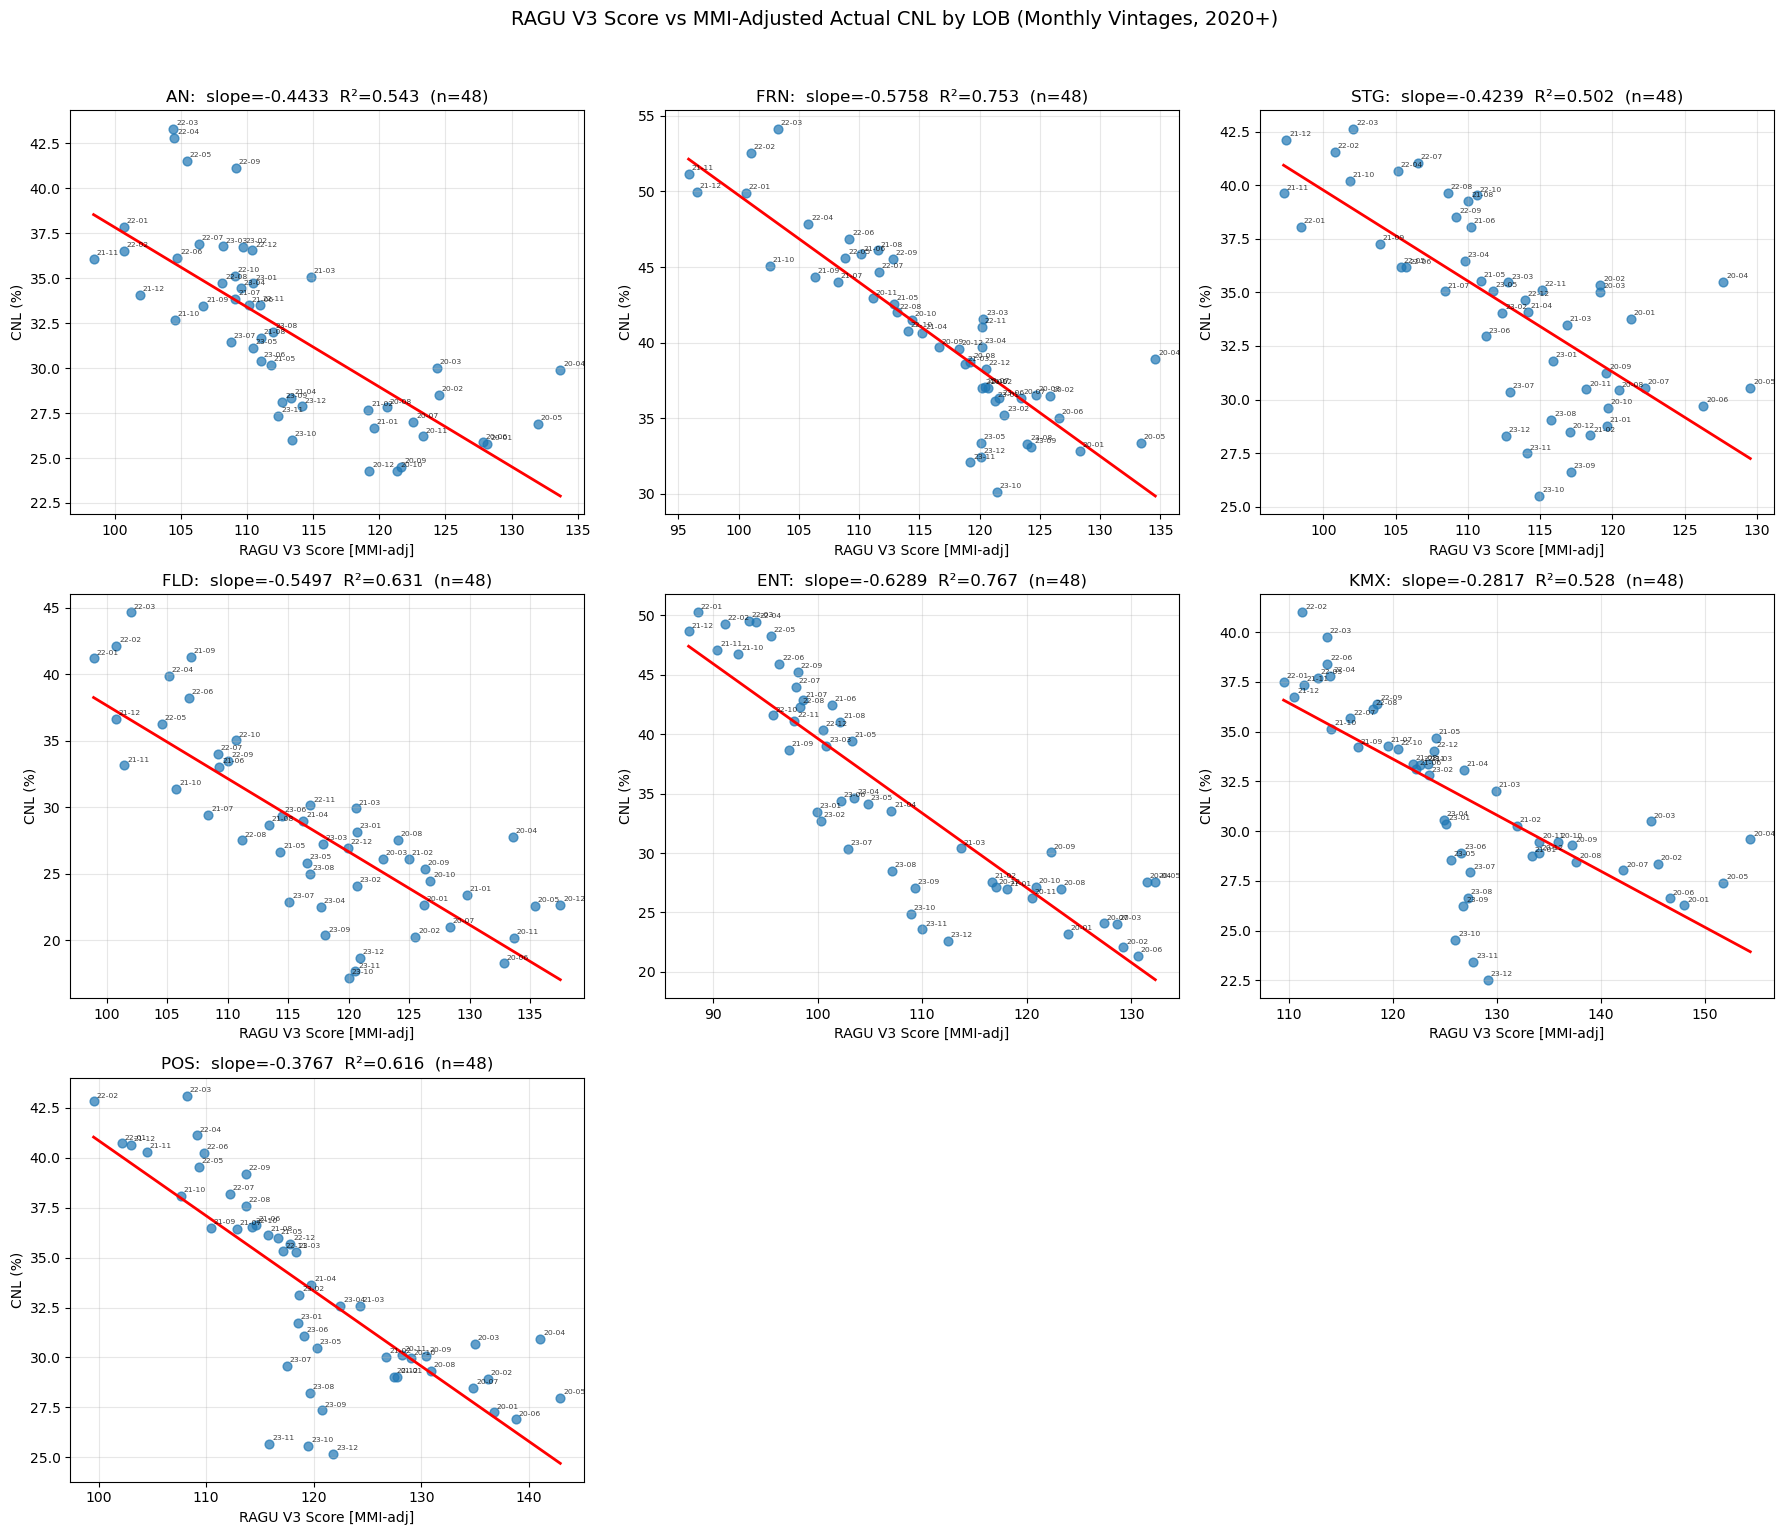


RAGU V3 VALIDATION: CNL Slope by LOB (per RAGU point)


,lob,slope,intercept,r_squared,p_value,n_vintages
0,AN,-0.4433,82.1450,0.5433,0.0,48
1,FRN,-0.5758,107.3378,0.7531,0.0,48
2,STG,-0.4239,82.1533,0.5020,0.0,48
3,FLD,-0.5497,92.6249,0.6309,0.0,48
4,ENT,-0.6289,102.5326,0.7672,0.0,48
5,KMX,-0.2817,67.4251,0.5284,0.0,48
6,POS,-0.3767,78.5298,0.6163,0.0,48



Interpretation: Higher RAGU = better risk (lower expected loss).
A negative slope confirms RAGU correctly orders risk: higher score -> lower CNL.


In [11]:
# =============================================================================
# CELL 11: VALIDATION -- CNL vs RAGU V3 SCORE SLOPE ANALYSIS
# =============================================================================

# Prepare RAGU scores for merge
ragu_scores = all_df[['lob', 'vintage', 'ragu_score', 'ms_original',
                       'gross_loss_impact', 'recovery_impact', 'ltv_impact',
                       'apr_impact', 'amt_financed_x']].copy()
ragu_scores = ragu_scores.rename(columns={'amt_financed_x': 'ragu_amt_financed'})

# Merge RAGU scores with CNL actuals
validation_df = ragu_scores.merge(cnl_by_lob_vintage[['lob', 'vintage', 'cnl_rate', 'gl_rate', 'loan_count']],
                                   on=['lob', 'vintage'], how='inner')

# Filter to mature vintages only (book month <= 2023 M12 for sufficient seasoning)
MATURITY_CUTOFF = '2023 M12'
validation_df = validation_df[validation_df['vintage'] <= MATURITY_CUTOFF].copy()

# --- MMI Market Adjustment (optional) ---
# Adjusts RAGU score to incorporate market conditions at expected repo time.
# Higher MMI at repo = better recovery = lower actual CNL.
# RAGU should be adjusted UP when MMI appreciation is expected.
if MMI_ENABLED:
    mmi_raw = pd.read_csv('../output/mmi_2019_seasonality.csv', header=None, names=['month_str', 'mmi'])
    mmi_raw = mmi_raw.dropna(subset=['mmi'])
    mmi_raw['date'] = pd.to_datetime(mmi_raw['month_str'], format='%b-%y')
    mmi_raw = mmi_raw.sort_values('date').reset_index(drop=True)
    mmi_raw['mmi_at_repo'] = mmi_raw['mmi'].shift(-MMI_LAG_MONTHS)
    mmi_raw['mmi_pct_change_24m'] = (mmi_raw['mmi_at_repo'] - mmi_raw['mmi']) / mmi_raw['mmi']
    mmi_raw['vintage'] = (mmi_raw['date'].dt.year.astype(str) + ' M'
                          + mmi_raw['date'].dt.month.astype(str).str.zfill(2))
    mmi_for_merge = mmi_raw[['vintage', 'mmi_pct_change_24m']].dropna()
    validation_df = validation_df.merge(mmi_for_merge, on='vintage', how='left')

    if MMI_COEF is None:
        import statsmodels.api as _sm
        _valid = validation_df[validation_df['mmi_pct_change_24m'].notna() &
                               validation_df['lob'].isin(LOBS)].copy()
        _X = _sm.add_constant(_valid[['ragu_score', 'mmi_pct_change_24m']])
        _model = _sm.OLS(_valid['cnl_rate'], _X).fit()
        _beta_ragu = _model.params['ragu_score']
        _beta_mmi = _model.params['mmi_pct_change_24m']
        MMI_COEF = _beta_mmi / _beta_ragu
        print(f"MMI coefficient auto-derived: {MMI_COEF:.4f} RAGU pts per 1.0 mmi_pct_change")
        print(f"  (from OLS: beta_ragu={_beta_ragu:.6f}, beta_mmi={_beta_mmi:.6f})")

    validation_df['ragu_score_orig'] = validation_df['ragu_score']
    mmi_mask = validation_df['mmi_pct_change_24m'].notna()
    validation_df.loc[mmi_mask, 'ragu_score'] = (
        validation_df.loc[mmi_mask, 'ragu_score']
        + MMI_COEF * validation_df.loc[mmi_mask, 'mmi_pct_change_24m']
    )
    print(f"MMI RAGU adjustment applied: {mmi_mask.sum()} vintages adjusted")

print(f"Validation set: {len(validation_df)} rows ({validation_df['lob'].nunique()} LOBs, "
      f"{validation_df['vintage'].nunique()} vintages)")
print(f"Vintage range: {validation_df['vintage'].min()} to {validation_df['vintage'].max()}")

# --- Per-LOB + POS slope analysis ---
VALIDATION_LOBS = LOBS + ['POS']
slope_results = []

n_plots = len(VALIDATION_LOBS)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes_flat = axes.flatten()

for i, lob in enumerate(VALIDATION_LOBS):
    ax = axes_flat[i]
    lob_data = validation_df[validation_df['lob'] == lob].copy()

    if len(lob_data) < 3:
        ax.set_title(f"{lob} (insufficient data)")
        slope_results.append({'lob': lob, 'slope': np.nan, 'intercept': np.nan,
                              'r_squared': np.nan, 'n_vintages': len(lob_data)})
        continue

    x = lob_data['ragu_score'].values
    y = lob_data['cnl_rate'].values * 100  # Convert to percentage

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r_sq = r_value ** 2

    slope_results.append({
        'lob': lob, 'slope': slope, 'intercept': intercept,
        'r_squared': r_sq, 'p_value': p_value, 'n_vintages': len(lob_data)
    })

    ax.scatter(x, y, alpha=0.7, s=40)
    x_fit = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, 'r-', linewidth=2)

    # Data labels showing vintage
    for _, row in lob_data.iterrows():
        v = row['vintage']  # e.g. '2022 M06'
        label = v[2:4] + '-' + v[-2:]  # e.g. '22-06'
        ax.annotate(label, (row['ragu_score'], row['cnl_rate'] * 100),
                    fontsize=5.5, alpha=0.75, ha='left', va='bottom',
                    xytext=(2, 2), textcoords='offset points')

    ax.set_xlabel('RAGU V3 Score' + (' [MMI-adj]' if MMI_ENABLED else ''))
    ax.set_ylabel('CNL (%)')
    ax.set_title(f"{lob}:  slope={slope:.4f}  R²={r_sq:.3f}  (n={len(lob_data)})")
    ax.grid(True, alpha=0.3)

for j in range(n_plots, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('RAGU V3 Score vs ' + ('MMI-Adjusted ' if MMI_ENABLED else '') + 'Actual CNL by LOB (Monthly Vintages, 2020+)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('v3_cnl_validation_by_lob.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary Table ---
slope_summary = pd.DataFrame(slope_results)
print("\n" + "=" * 70)
print("RAGU V3 VALIDATION: CNL Slope by LOB (per RAGU point)")
print("=" * 70)
display(slope_summary.round(4))

print(f"\nInterpretation: Higher RAGU = better risk (lower expected loss).")
print(f"A negative slope confirms RAGU correctly orders risk: higher score -> lower CNL.")

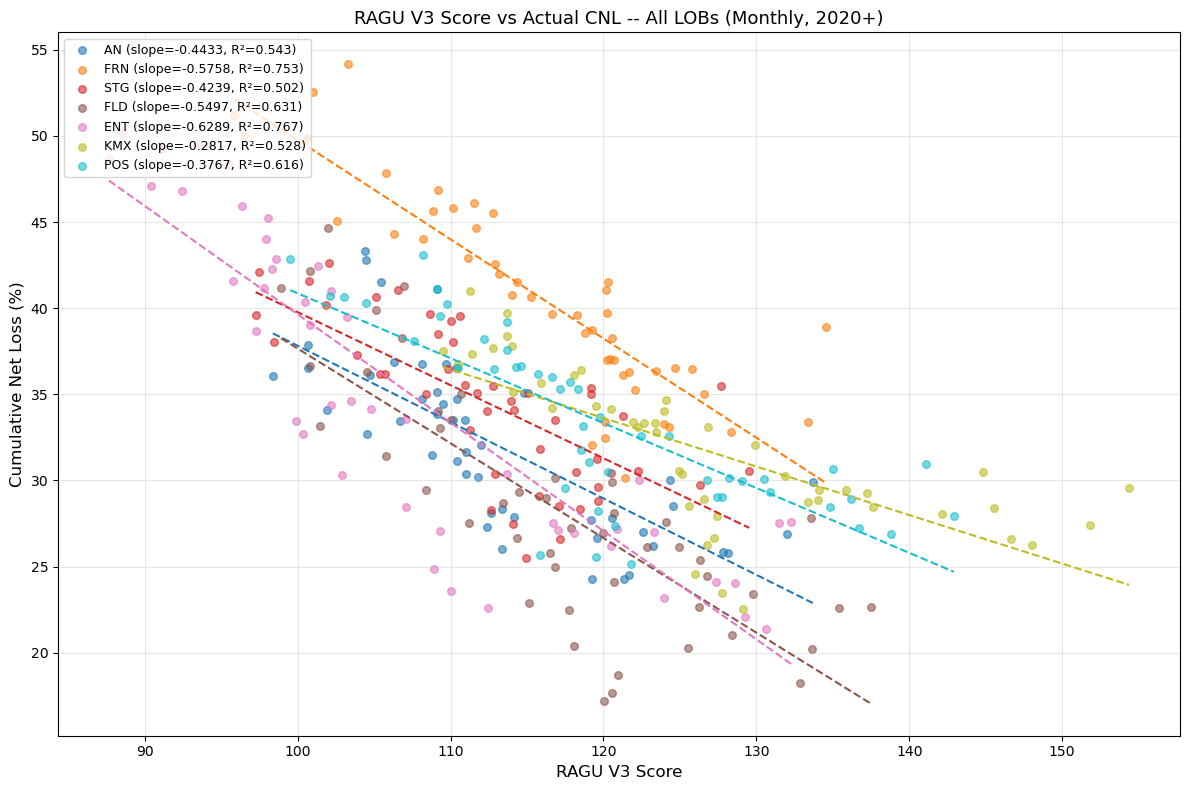


RAGU V3 FORMULA SUMMARY (UL-based)
  UL = 0.9 - (MS - 125)*0.027 - (72 - term)/240
  RAGU_V3 = Model_Score
          + (1 - Loss_Multiplier) * UL / 0.027
          - UL * 0.75 * Recovery_Multiplier * 100
          + 1.1 * (LTV_baseline - LTV)
          + (APR_baseline - APR) / 0.01 * 0.8223

  Key parameters:
    Find rate (F): 0.75
    LTV coefficient: 1.1 (= beta_ltv * F * GL_mult)
    APR multiplier: 0.8223
    UL at mean (MS=136, term=68): 0.5863
    Implied GL mult at mean: 21.72


In [12]:
# =============================================================================
# CELL 12: COMBINED VALIDATION PANEL
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

PLOT_LOBS = LOBS + ['POS']
colors = plt.cm.tab10(np.linspace(0, 1, len(PLOT_LOBS)))

for i, lob in enumerate(PLOT_LOBS):
    lob_data = validation_df[validation_df['lob'] == lob]
    if len(lob_data) < 3:
        continue
    x = lob_data['ragu_score'].values
    y = lob_data['cnl_rate'].values * 100
    slope, intercept, r_value, _, _ = linregress(x, y)

    ax.scatter(x, y, color=colors[i], alpha=0.6, s=30, label=f"{lob} (slope={slope:.4f}, R²={r_value**2:.3f})")
    x_fit = np.linspace(x.min(), x.max(), 50)
    ax.plot(x_fit, slope * x_fit + intercept, color=colors[i], linewidth=1.5, linestyle='--')

ax.set_xlabel('RAGU V3 Score', fontsize=12)
ax.set_ylabel('Cumulative Net Loss (%)', fontsize=12)
ax.set_title('RAGU V3 Score vs Actual CNL -- All LOBs (Monthly, 2020+)', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('v3_cnl_validation_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print formula summary ---
print("\n" + "=" * 70)
print("RAGU V3 FORMULA SUMMARY (UL-based)")
print("=" * 70)
print(f"  UL = {UL_INTERCEPT} - (MS - {UL_MS_CENTER})*{UL_TO_MS} - ({UL_TERM_CENTER} - term)/{UL_TERM_DENOM}")
print(f"  RAGU_V3 = Model_Score")
print(f"          + (1 - Loss_Multiplier) * UL / {UL_TO_MS}")
print(f"          - UL * {FIND_RATE} * Recovery_Multiplier * {RECOVERY_TO_SCORE}")
print(f"          + {LTV_COEF} * (LTV_baseline - LTV)")
print(f"          + (APR_baseline - APR) / 0.01 * {APR_MULT}")
print(f"\n  Key parameters:")
print(f"    Find rate (F): {FIND_RATE}")
print(f"    LTV coefficient: {LTV_COEF} (= beta_ltv * F * GL_mult)")
print(f"    APR multiplier: {APR_MULT}")
print(f"    UL at mean (MS=136, term=68): {compute_unit_loss(136, 68):.4f}")
print(f"    Implied GL mult at mean: {compute_unit_loss(136, 68)/UL_TO_MS:.2f}")

In [13]:
# =============================================================================
# CELL 13: LOAN-LEVEL VALIDATION (individual, irrespective of vintage)
# =============================================================================
# Computes RAGU V3 score at the individual loan level and regresses against
# actual net loss outcome. This removes vintage/macro noise and should recover
# the cross-sectional R-squared seen in the component studies.

# --- Build loan-level RAGU scores from ULA data ---
loan_df = ula_df_total.copy()

# Apply ULA multipliers per-loan (KMX vs nonKMX)
kmx_mask = loan_df.lob == 'KMX'
nonkmx_df = loan_df[~kmx_mask].copy()
kmx_df = loan_df[kmx_mask].copy()

if len(nonkmx_df) > 0:
    nonkmx_df = get_ula_multiplier_nonkmx(nonkmx_df)
if len(kmx_df) > 0:
    kmx_df = get_ula_multiplier_kmx(kmx_df)

loan_df = pd.concat([nonkmx_df, kmx_df], ignore_index=True)

# Merge recovery multiplier
nr_unique = new_recovery[['account_number', 'new_recovery_multiplier']].drop_duplicates(
    subset='account_number', keep='first')
loan_df = loan_df.merge(
    nr_unique.rename(columns={'new_recovery_multiplier': 'recovery_multiplier'}),
    on='account_number', how='left'
)

# Compute LTV
loan_df['ltv'] = loan_df.amt_financed / loan_df.bbvalue.replace(0, np.nan)

# Map baselines
loan_df['baseline_ltv'] = loan_df['lob'].map({k: v['ltv'] for k, v in BASELINES.items()})
loan_df['baseline_apr'] = loan_df['lob'].map({k: v['apr'] for k, v in BASELINES.items()})

# --- Compute V3 RAGU score per loan ---
loan_df['con_term_filled'] = loan_df['con_term'].fillna(UL_TERM_CENTER)
loan_df['unit_loss'] = compute_unit_loss(loan_df['cd_model_score'], loan_df['con_term_filled'])
loan_df['gl_impact'] = compute_gross_loss_impact(loan_df['loss_multiplier'], loan_df['unit_loss'])
loan_df['recovery_impact'] = compute_recovery_impact(loan_df['recovery_multiplier'].fillna(0), loan_df['unit_loss'])
loan_df['ltv_impact'] = compute_ltv_impact(loan_df['baseline_ltv'], loan_df['ltv'].fillna(loan_df['baseline_ltv']))
loan_df['apr_impact'] = compute_apr_impact(loan_df['baseline_apr'], loan_df['apr'])

# KMX rescaling
kmx_mask_final = loan_df.lob == 'KMX'
loan_df.loc[kmx_mask_final, 'cd_model_score'] = rescale_kmx(
    loan_df.loc[kmx_mask_final, 'cd_model_score'], is_model_score=True)
for col in ['gl_impact', 'recovery_impact', 'ltv_impact', 'apr_impact']:
    loan_df.loc[kmx_mask_final, col] = loan_df.loc[kmx_mask_final, col] * KMX_BPS_PER_POINT

loan_df['ragu_v3'] = (
    loan_df['cd_model_score']
    + loan_df['gl_impact']
    - loan_df['recovery_impact']
    + loan_df['ltv_impact']
    + loan_df['apr_impact']
)

print(f"Loan-level RAGU scores: {len(loan_df):,} loans")
print(f"RAGU V3 range: [{loan_df['ragu_v3'].min():.1f}, {loan_df['ragu_v3'].max():.1f}]")
print(f"RAGU V3 mean: {loan_df['ragu_v3'].mean():.2f}, std: {loan_df['ragu_v3'].std():.2f}")

Loan-level RAGU scores: 879,389 loans
RAGU V3 range: [-0.7, 261.5]
RAGU V3 mean: 120.29, std: 17.96


Loan-level validation set: 362,788 loans
LOBs: ['AN', 'ENT', 'FLD', 'FRN', 'KMX', 'STG']
Mean CNL: 0.3456
Mean RAGU V3: 116.61


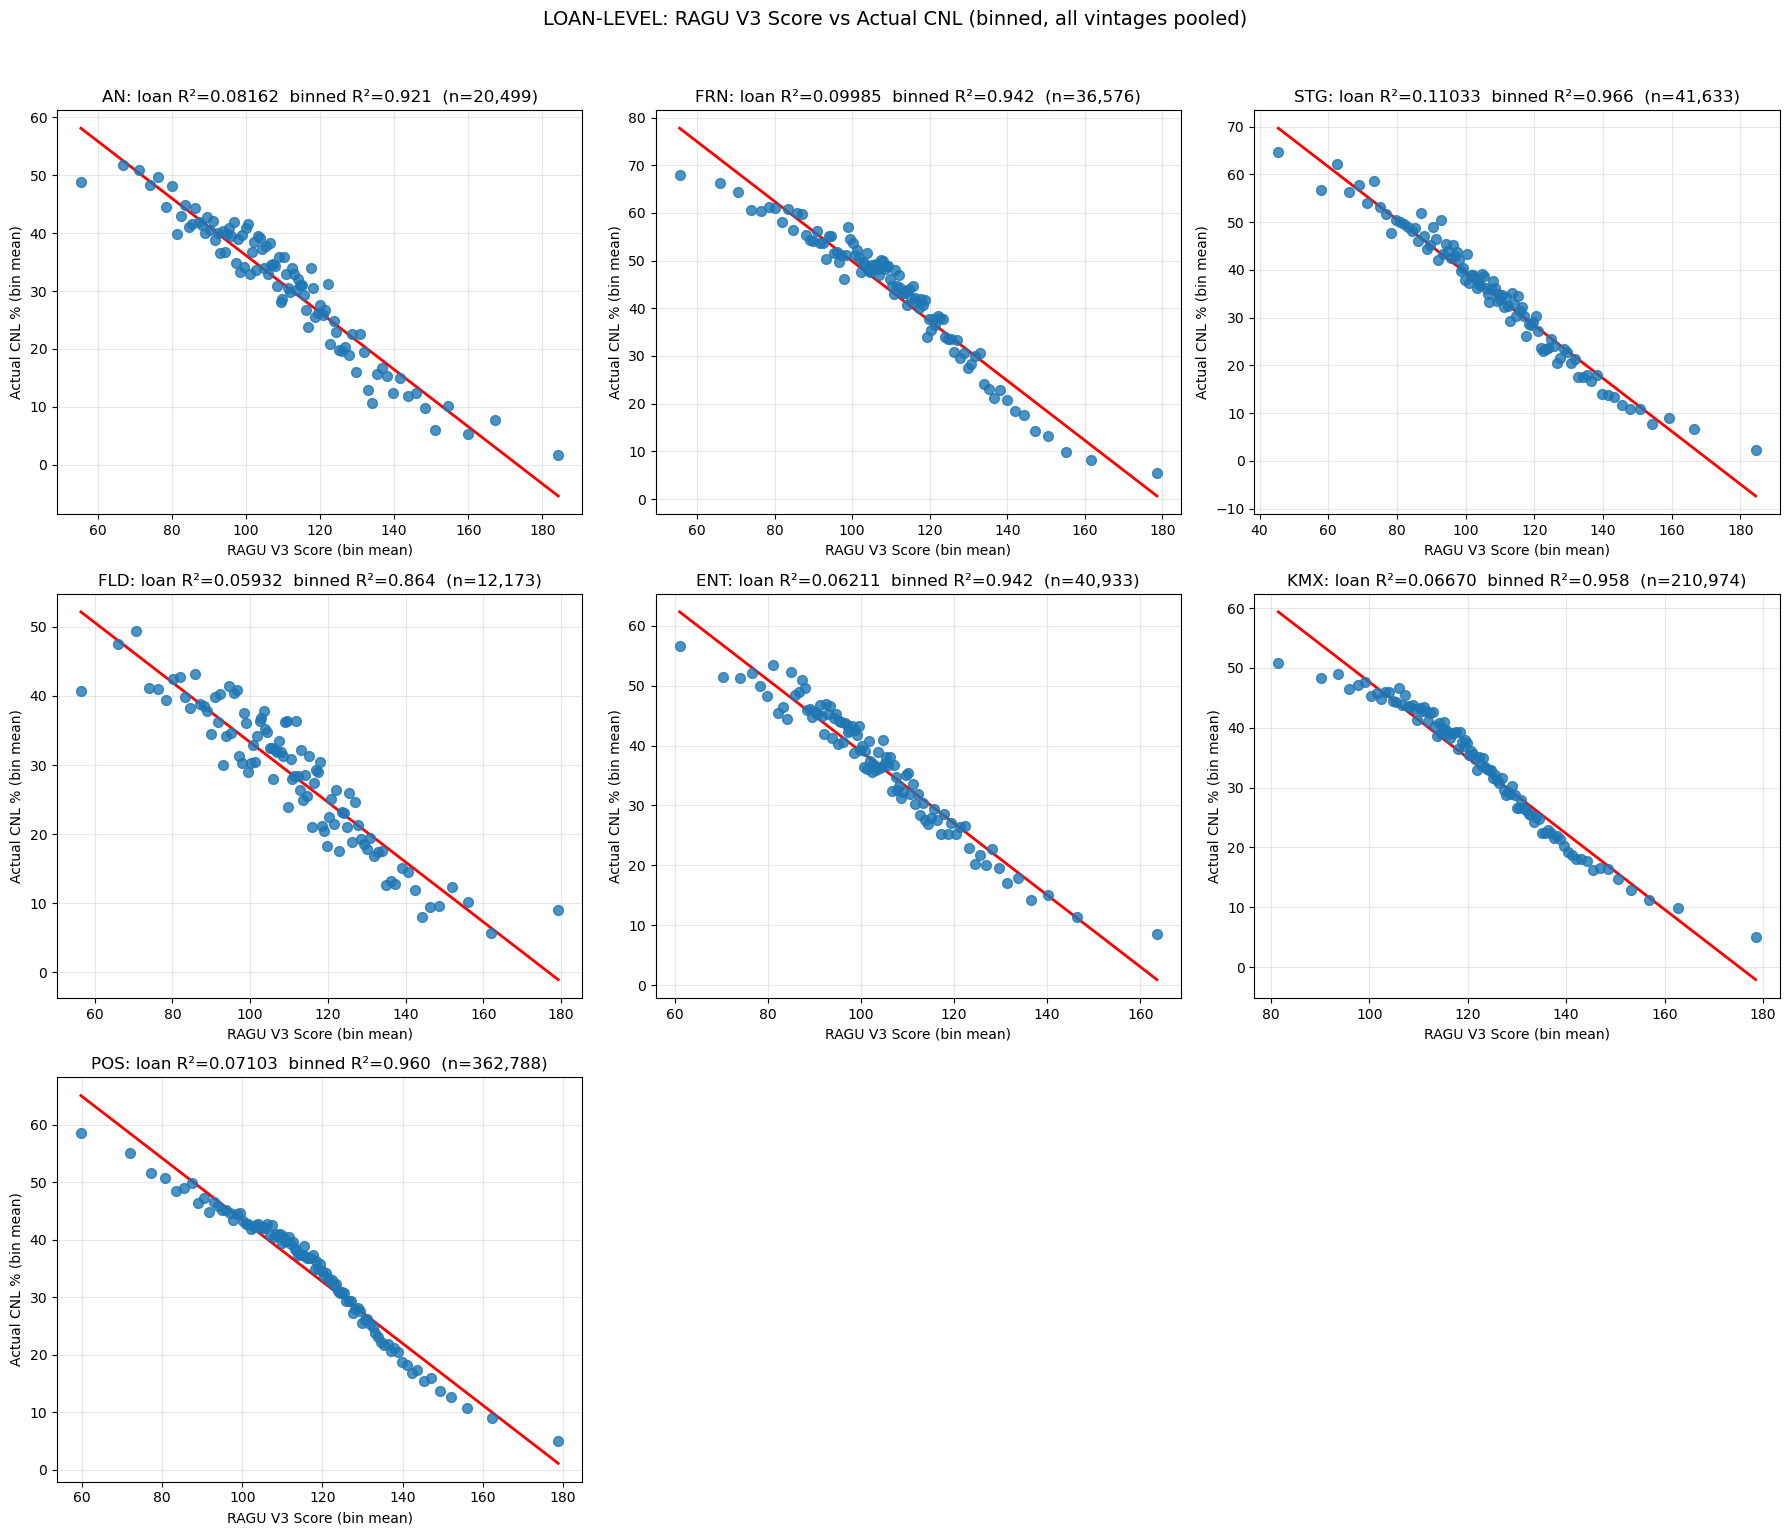


LOAN-LEVEL VALIDATION: RAGU V3 vs Actual CNL

  loan R²  = raw loan-level OLS (comparable to component studies' ~0.085)
  binned R² = 50-bin aggregated (comparable to component studies' ~0.96-0.99)



,lob,slope,r_squared_loan,r_squared_binned,n_loans
0,AN,-0.00492,0.08162,0.92081,20499
1,FRN,-0.00625,0.09985,0.94177,36576
2,STG,-0.00552,0.11033,0.96567,41633
3,FLD,-0.00432,0.05932,0.86369,12173
4,ENT,-0.00595,0.06211,0.94202,40933
5,KMX,-0.00631,0.06670,0.95818,210974
6,POS,-0.00536,0.07103,0.96001,362788



For reference, gross loss study found:
  Loan-level R²: 0.08550 (M5 OLS-optimal)
  Binned R²:     0.989 (V1), 0.984 (V2)

Recovery study found:
  Loan-level R²: 0.07738 (M3 additive)
  Binned R²:     0.962 (decoupled formula)


In [14]:
# =============================================================================
# CELL 14: LOAN-LEVEL CNL MERGE AND REGRESSION
# =============================================================================

# Merge loan-level RAGU with actuals (net_loss_amt, proceeds)
loan_actuals = loan_df[['account_number', 'lob', 'ragu_v3', 'cd_model_score',
                         'gl_impact', 'recovery_impact', 'ltv_impact', 'apr_impact']].copy()
loan_actuals = loan_actuals.merge(
    actuals_df.drop(columns='vintage')[['account_number', 'proceeds', 'net_loss_amt', 'gross_loss_amt']],
    on='account_number', how='inner'
)

# Compute loan-level CNL rate
loan_actuals['cnl_pct'] = loan_actuals['net_loss_amt'] / loan_actuals['proceeds']
loan_actuals['gl_pct'] = loan_actuals['gross_loss_amt'] / loan_actuals['proceeds']

# Filter to valid rows
loan_actuals = loan_actuals[loan_actuals['proceeds'] > 0].copy()
loan_actuals = loan_actuals[loan_actuals['ragu_v3'].notna()].copy()

# Apply maturity filter: only keep loans booked early enough to have seasoned
MATURITY_CUTOFF_DATE = '2022-12-31'
loan_with_date = loan_actuals.merge(
    ula_df_total[['account_number', 'book_date']].drop_duplicates(subset='account_number', keep='first'),
    on='account_number', how='left'
)
loan_with_date = loan_with_date[loan_with_date['book_date'] <= MATURITY_CUTOFF_DATE]

print(f"Loan-level validation set: {len(loan_with_date):,} loans")
print(f"LOBs: {sorted(loan_with_date['lob'].unique())}")
print(f"Mean CNL: {loan_with_date['cnl_pct'].mean():.4f}")
print(f"Mean RAGU V3: {loan_with_date['ragu_v3'].mean():.2f}")

# --- Loan-level OLS regression per LOB + POS ---
VALIDATION_LOBS_INDIV = LOBS + ['POS']
indiv_results = []

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes_flat = axes.flatten()

for i, lob in enumerate(VALIDATION_LOBS_INDIV):
    ax = axes_flat[i]
    if lob == 'POS':
        lob_data = loan_with_date.copy()
    else:
        lob_data = loan_with_date[loan_with_date['lob'] == lob].copy()

    if len(lob_data) < 100:
        ax.set_title(f"{lob} (insufficient data)")
        indiv_results.append({'lob': lob, 'slope': np.nan, 'r_squared_loan': np.nan,
                              'r_squared_binned': np.nan, 'n_loans': len(lob_data)})
        continue

    x = lob_data['ragu_v3'].values
    y = lob_data['cnl_pct'].values

    # Loan-level R-squared
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r_sq_loan = r_value ** 2

    # Binned R-squared (50 equal-sized bins for fair comparison with studies)
    lob_data['ragu_bin'] = pd.qcut(lob_data['ragu_v3'], 100, duplicates='drop')
    binned = lob_data.groupby('ragu_bin', observed=True).agg(
        mean_ragu=('ragu_v3', 'mean'),
        mean_cnl=('cnl_pct', 'mean'),
        n=('account_number', 'count')
    ).reset_index()

    if len(binned) >= 5:
        slope_b, intercept_b, r_b, _, _ = linregress(binned['mean_ragu'], binned['mean_cnl'])
        r_sq_binned = r_b ** 2
    else:
        r_sq_binned = np.nan

    indiv_results.append({
        'lob': lob, 'slope': slope, 'r_squared_loan': r_sq_loan,
        'r_squared_binned': r_sq_binned, 'n_loans': len(lob_data)
    })

    # Plot binned means
    ax.scatter(binned['mean_ragu'], binned['mean_cnl'] * 100, alpha=0.8, s=50, zorder=3)
    x_fit = np.linspace(binned['mean_ragu'].min(), binned['mean_ragu'].max(), 100)
    ax.plot(x_fit, (slope_b * x_fit + intercept_b) * 100, 'r-', linewidth=2)
    ax.set_xlabel('RAGU V3 Score (bin mean)')
    ax.set_ylabel('Actual CNL % (bin mean)')
    ax.set_title(f"{lob}: loan R\u00b2={r_sq_loan:.5f}  binned R\u00b2={r_sq_binned:.3f}  (n={len(lob_data):,})")
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(len(VALIDATION_LOBS_INDIV), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('LOAN-LEVEL: RAGU V3 Score vs Actual CNL (binned, all vintages pooled)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('v3_cnl_validation_loan_level.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary comparison table ---
indiv_summary = pd.DataFrame(indiv_results)
print("\n" + "=" * 80)
print("LOAN-LEVEL VALIDATION: RAGU V3 vs Actual CNL")
print("=" * 80)
print("\n  loan R\u00b2  = raw loan-level OLS (comparable to component studies' ~0.085)")
print("  binned R\u00b2 = 50-bin aggregated (comparable to component studies' ~0.96-0.99)")
print()
display(indiv_summary.round(5))

print(f"\nFor reference, gross loss study found:")
print(f"  Loan-level R\u00b2: 0.08550 (M5 OLS-optimal)")
print(f"  Binned R\u00b2:     0.989 (V1), 0.984 (V2)")
print(f"\nRecovery study found:")
print(f"  Loan-level R\u00b2: 0.07738 (M3 additive)")
print(f"  Binned R\u00b2:     0.962 (decoupled formula)")

In [15]:
# =============================================================================
# CELL 15: SENSITIVITY ANALYSIS -- RE-SCORE UNDER EXTREME COEFFICIENT SETS
# =============================================================================

from scipy.stats import linregress as lr_func

scenario_results = {}

for scenario_name, scenario_params in SCENARIOS.items():
    s_results = []
    for lob in LOBS:
        baseline_config = BASELINES[lob]
        for vintage in all_vintages:
            try:
                result = get_ragu_v3_score(vintage, lob, ula_df_total, new_recovery,
                                           ms_df, baseline_config, scenario=scenario_params)
                if result is not None:
                    s_results.append(result)
            except Exception:
                pass

    if not s_results:
        continue

    s_all_df = pd.concat(s_results, ignore_index=False).reset_index()

    # Rollup POS
    pos_df = s_all_df[s_all_df.lob.isin(ROLLUP_GROUPS['POS'])].copy()
    pos_df = pos_df.rename(columns={'amt_financed_x': 'amt_financed'})
    pos_rollup = pos_df.groupby('vintage').apply(
        weighted_average_and_sum, ROLLUP_METRICS, include_groups=False
    ).reset_index()
    pos_rollup['lob'] = 'POS'

    s_all_with_pos = pd.concat([s_all_df.rename(columns={'amt_financed_x': 'amt_financed'}),
                                 pos_rollup], ignore_index=True)

    # Merge with actuals
    s_ragu = s_all_with_pos[['lob', 'vintage', 'ragu_score', 'ms_original',
                              'gross_loss_impact', 'recovery_impact',
                              'ltv_impact', 'apr_impact']].copy()

    s_val = s_ragu.merge(cnl_by_lob_vintage[['lob', 'vintage', 'cnl_rate', 'gl_rate', 'loan_count']],
                          on=['lob', 'vintage'], how='inner')

    # Per-LOB slope regressions
    lob_stats = []
    for lob_name in sorted(s_val['lob'].unique()):
        lob_data = s_val[s_val['lob'] == lob_name]
        if len(lob_data) < 5:
            continue
        slope, intercept, r, p, _ = lr_func(lob_data['ragu_score'], lob_data['cnl_rate'])
        lob_stats.append({
            'lob': lob_name, 'slope': slope, 'intercept': intercept,
            'r_squared': r**2, 'n': len(lob_data)
        })

    scenario_results[scenario_name] = {
        'all_df': s_all_with_pos,
        'validation': s_val,
        'lob_stats': pd.DataFrame(lob_stats),
        'mean_ragu_pos': s_val[s_val['lob'] == 'POS']['ragu_score'].mean() if 'POS' in s_val['lob'].values else np.nan,
    }

print(f"Scored {len(SCENARIOS)} scenarios.")

# --- Summary table ---
print("\n" + "=" * 100)
print("SENSITIVITY ANALYSIS: SCENARIO COMPARISON")
print("=" * 100)

print(f"\n{'Scenario':<12} {'APR mult':>10} {'LTV coef':>10} {'F':>6} "
      f"{'POS R²':>8} {'POS slope':>10} {'Mean RAGU':>10} {'vs Base':>8}")
print("-" * 80)

base_mean = scenario_results['Base']['mean_ragu_pos']
for name, res in scenario_results.items():
    pos_stats = res['lob_stats'][res['lob_stats']['lob'] == 'POS']
    pos_r2 = pos_stats['r_squared'].values[0] if len(pos_stats) > 0 else np.nan
    pos_slope = pos_stats['slope'].values[0] if len(pos_stats) > 0 else np.nan
    mean_ragu = res['mean_ragu_pos']
    delta = mean_ragu - base_mean if not np.isnan(mean_ragu) else np.nan
    params = SCENARIOS[name]
    print(f"{name:<12} {params['apr_mult']:>10.4f} {params['ltv_coef']:>10.2f} {params['find_rate']:>6.2f} "
          f"{pos_r2:>8.4f} {pos_slope:>10.4f} {mean_ragu:>10.2f} {delta:>+8.2f}")

# --- Per-LOB R² comparison ---
print(f"\n{'=' * 100}")
print("PER-LOB R² BY SCENARIO")
print("=" * 100)

lobs_to_show = ['AN', 'FRN', 'STG', 'FLD', 'ENT', 'KMX', 'POS']
header = f"{'Scenario':<12}" + "".join(f"{l:>8}" for l in lobs_to_show)
print(f"\n{header}")
print("-" * (12 + 8 * len(lobs_to_show)))

for name, res in scenario_results.items():
    row = f"{name:<12}"
    for lob_name in lobs_to_show:
        lob_data = res['lob_stats'][res['lob_stats']['lob'] == lob_name]
        r2 = lob_data['r_squared'].values[0] if len(lob_data) > 0 else np.nan
        row += f"{r2:>8.4f}"
    print(row)

Scored 7 scenarios.

SENSITIVITY ANALYSIS: SCENARIO COMPARISON

Scenario       APR mult   LTV coef      F   POS R²  POS slope  Mean RAGU  vs Base
--------------------------------------------------------------------------------
Base             0.8223       1.10   0.75   0.5614    -0.0209     119.53    +0.00
APR High         0.9500       1.10   0.75   0.5630    -0.0209     119.53    +0.00
APR Low          0.7800       1.10   0.75   0.5608    -0.0209     119.53    -0.00
LTV High         0.8223       1.35   0.75   0.5635    -0.0209     119.55    +0.02
LTV Low          0.8223       0.81   0.75   0.5588    -0.0209     119.50    -0.03
F High           0.8223       1.10   0.81   0.5533    -0.0199     117.95    -1.58
F Low            0.8223       1.10   0.60   0.5845    -0.0238     123.47    +3.94

PER-LOB R² BY SCENARIO

Scenario          AN     FRN     STG     FLD     ENT     KMX     POS
--------------------------------------------------------------------
Base          0.5322  0.4554  0.4005

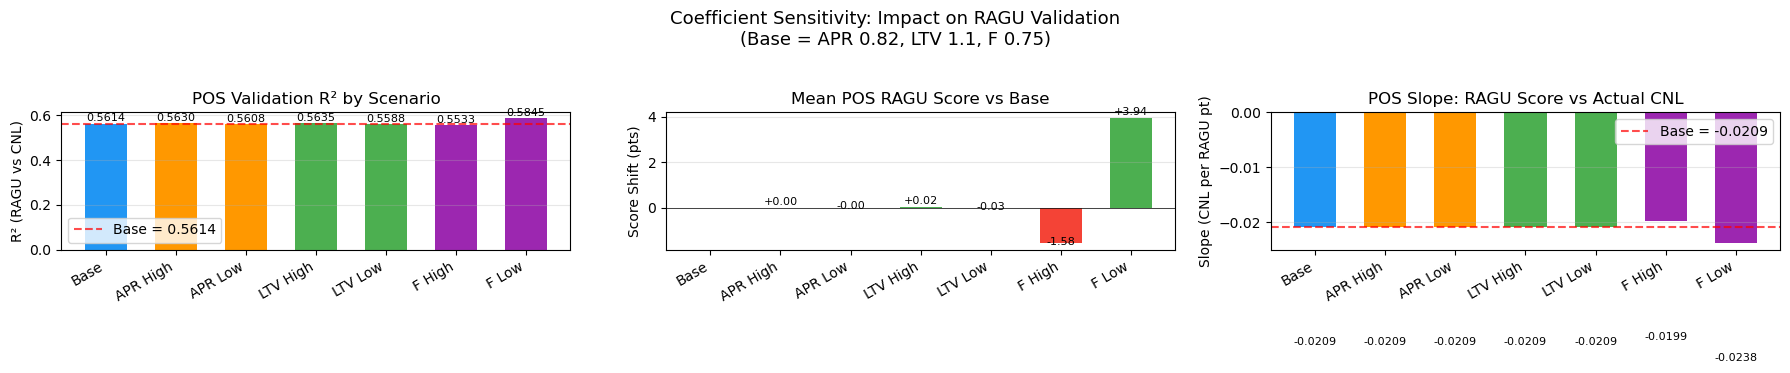

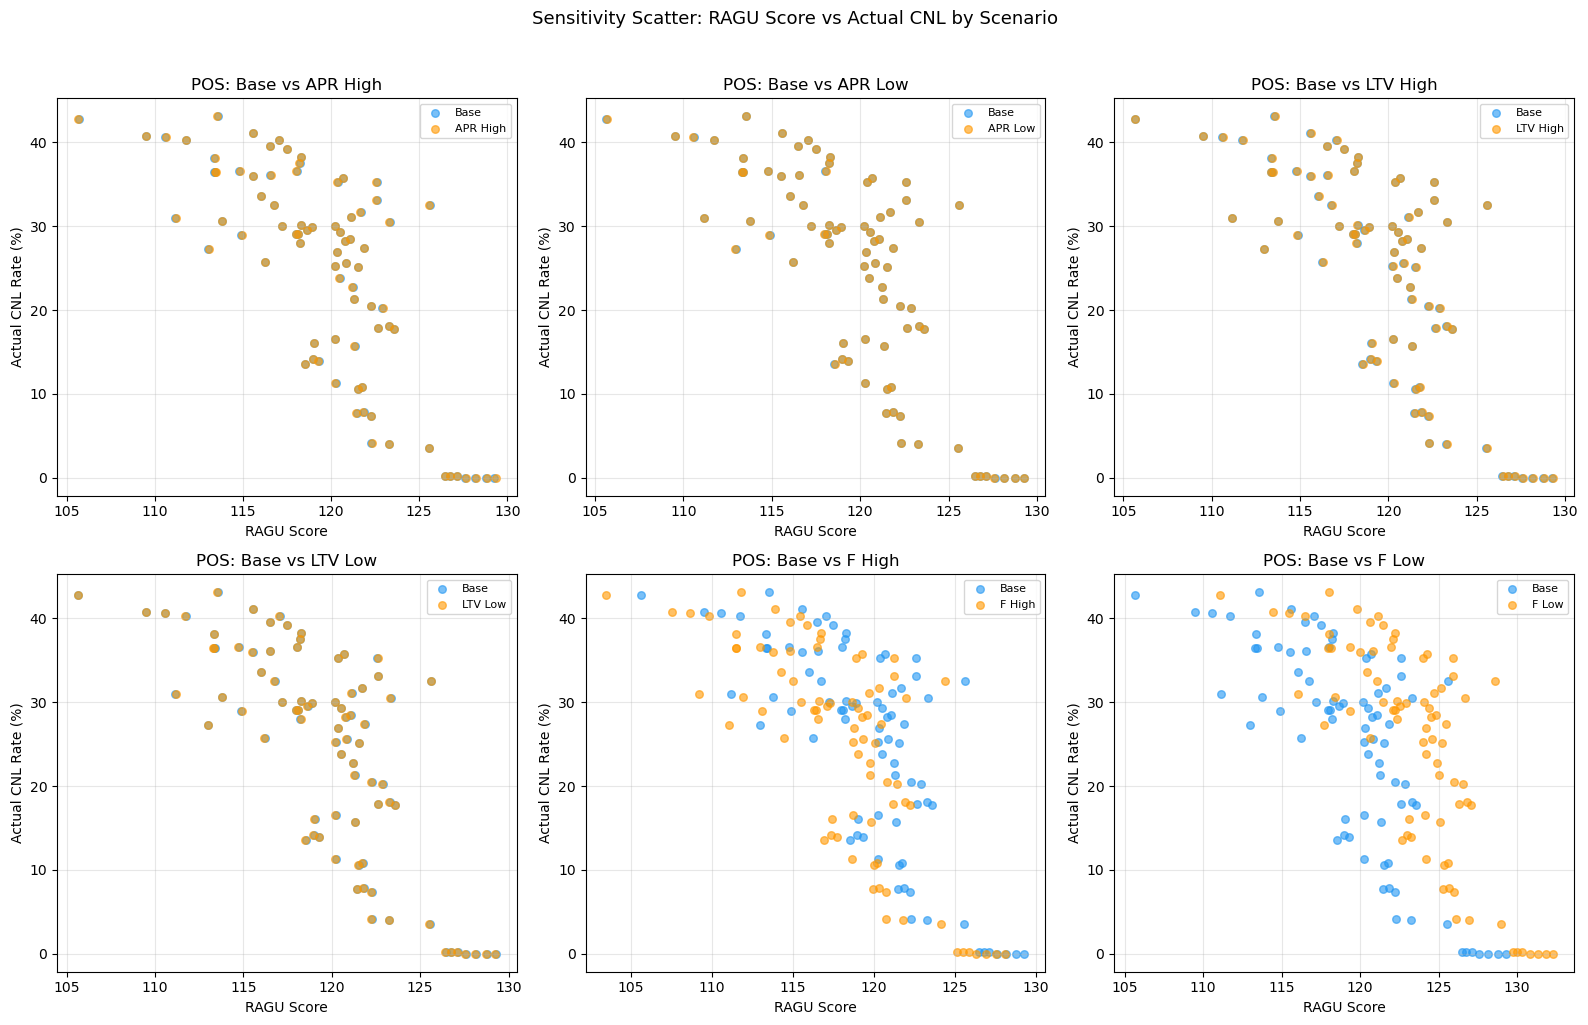

In [16]:
# =============================================================================
# CELL 16: SENSITIVITY VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

scenario_names = list(SCENARIOS.keys())
x = np.arange(len(scenario_names))
bar_width = 0.6
colors = ['#2196F3', '#FF9800', '#FF9800', '#4CAF50', '#4CAF50', '#9C27B0', '#9C27B0']

# Panel A: POS R² by scenario
ax = axes[0]
r2_vals = []
for name in scenario_names:
    pos_stats = scenario_results[name]['lob_stats']
    pos_row = pos_stats[pos_stats['lob'] == 'POS']
    r2_vals.append(pos_row['r_squared'].values[0] if len(pos_row) > 0 else 0)
ax.bar(x, r2_vals, bar_width, color=colors)
ax.axhline(y=r2_vals[0], color='red', linestyle='--', alpha=0.7, label=f"Base = {r2_vals[0]:.4f}")
ax.set_ylabel('R² (RAGU vs CNL)')
ax.set_title('POS Validation R² by Scenario')
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_vals):
    ax.text(i, v + 0.002, f"{v:.4f}", ha='center', va='bottom', fontsize=8)

# Panel B: Mean RAGU score shift
ax = axes[1]
mean_vals = [scenario_results[name]['mean_ragu_pos'] for name in scenario_names]
delta_vals = [m - mean_vals[0] for m in mean_vals]
bar_colors = ['#2196F3' if d == 0 else ('#4CAF50' if d > 0 else '#F44336') for d in delta_vals]
ax.bar(x, delta_vals, bar_width, color=bar_colors)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Score Shift (pts)')
ax.set_title('Mean POS RAGU Score vs Base')
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=30, ha='right')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(delta_vals):
    if v != 0:
        ax.text(i, v + (0.05 if v > 0 else -0.15), f"{v:+.2f}", ha='center', va='bottom', fontsize=8)

# Panel C: POS slope magnitude (closer to -1 = better calibration)
ax = axes[2]
slope_vals = []
for name in scenario_names:
    pos_stats = scenario_results[name]['lob_stats']
    pos_row = pos_stats[pos_stats['lob'] == 'POS']
    slope_vals.append(pos_row['slope'].values[0] if len(pos_row) > 0 else 0)
ax.bar(x, slope_vals, bar_width, color=colors)
ax.axhline(y=slope_vals[0], color='red', linestyle='--', alpha=0.7, label=f"Base = {slope_vals[0]:.4f}")
ax.set_ylabel('Slope (CNL per RAGU pt)')
ax.set_title('POS Slope: RAGU Score vs Actual CNL')
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(slope_vals):
    ax.text(i, v - 0.02, f"{v:.4f}", ha='center', va='top', fontsize=8)

plt.suptitle('Coefficient Sensitivity: Impact on RAGU Validation\n'
             '(Base = APR 0.82, LTV 1.1, F 0.75)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_validation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Scatter: Base vs extremes for POS ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
scenarios_to_plot = [s for s in scenario_names if s != 'Base']

for idx, name in enumerate(scenarios_to_plot):
    ax = axes[idx // 3, idx % 3]
    base_val = scenario_results['Base']['validation']
    alt_val = scenario_results[name]['validation']

    base_pos = base_val[base_val['lob'] == 'POS'].sort_values('vintage')
    alt_pos = alt_val[alt_val['lob'] == 'POS'].sort_values('vintage')

    ax.scatter(base_pos['ragu_score'], base_pos['cnl_rate'] * 100, s=30, alpha=0.6, label='Base', color='#2196F3')
    ax.scatter(alt_pos['ragu_score'], alt_pos['cnl_rate'] * 100, s=30, alpha=0.6, label=name, color='#FF9800')
    ax.set_xlabel('RAGU Score')
    ax.set_ylabel('Actual CNL Rate (%)')
    ax.set_title(f'POS: Base vs {name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensitivity Scatter: RAGU Score vs Actual CNL by Scenario', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Tested 3 UL_TO_MS values: [0.024, 0.027, 0.031]

UL_TO_MS SENSITIVITY: EFFECT OF ANCHOR HEURISTIC ON SCORING

  UL_TO_MS   POS R²  POS slope  Mean RAGU vs 0.027  Mean GL Mean Rec
---------------------------------------------------------------------------
     0.024   0.5088    -0.0225     118.94    -1.12     0.92    24.07
     0.027   0.5325    -0.0216     120.06    +0.00     0.75    22.62 <-- base
     0.031   0.5602    -0.0205     121.61    +1.55     0.58    20.69


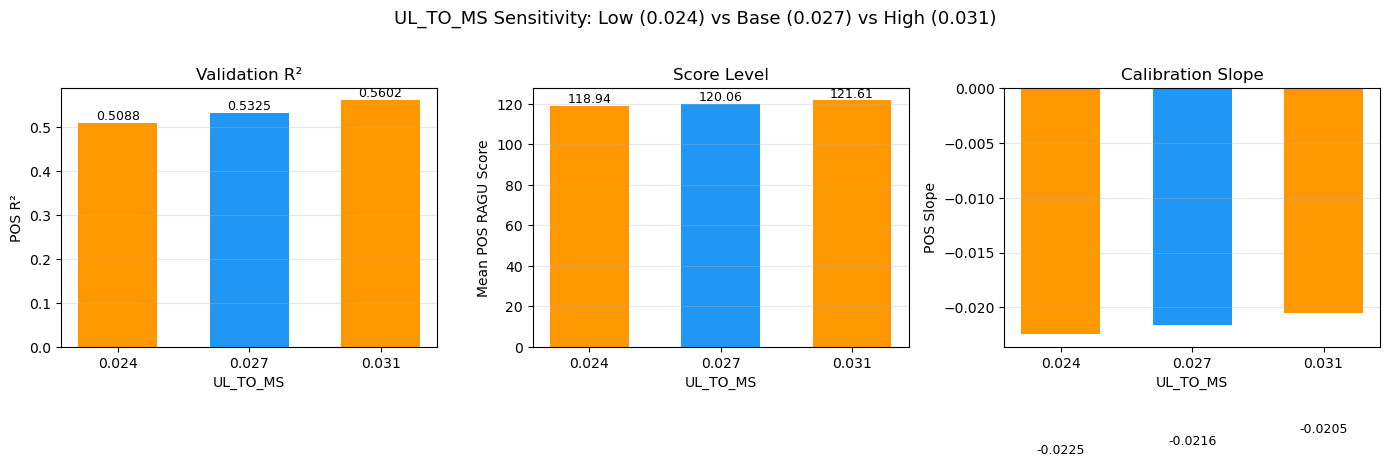

In [19]:
# =============================================================================
# CELL 17: UL_TO_MS SENSITIVITY -- TEST THE 0.027 ANCHOR HEURISTIC
# =============================================================================
# The 0.027 factor appears in two places:
#   1. UL = 0.9 - (MS - 125) * ul_to_ms - (72 - term) / 240
#   2. GL impact = (1 - LM) * UL / ul_to_ms
# Changing it affects both the UL magnitude AND the GL divisor (compounding).

UL_TO_MS_RANGE = [0.024, 0.027, 0.031]

def compute_unit_loss_custom(model_score, con_term, ul_to_ms):
    return UL_INTERCEPT - (model_score - UL_MS_CENTER) * ul_to_ms - (UL_TERM_CENTER - con_term) / UL_TERM_DENOM


def score_with_ul_to_ms(vintage, lob, ula_data, nr_data, ms_data, baseline_config, ul_to_ms):
    """Re-score a single vintage/LOB with a custom UL_TO_MS value."""
    result = get_ragu_v3_score(vintage, lob, ula_data, nr_data, ms_data, baseline_config, scenario=None)
    if result is None:
        return None

    # Recompute with custom ul_to_ms (overrides the base scoring)
    result['unit_loss_custom'] = compute_unit_loss_custom(
        result['model_score'], result['con_term'].fillna(UL_TERM_CENTER), ul_to_ms)
    result['gross_loss_impact'] = (1 - result['loss_multiplier']) * result['unit_loss_custom'] / ul_to_ms
    result['recovery_impact'] = result['unit_loss_custom'] * FIND_RATE * result['recovery_unadjusted_multiplier'] * RECOVERY_TO_SCORE

    baseline_ltv = baseline_config['ltv']
    baseline_apr = baseline_config['apr']
    result['ltv_impact'] = compute_ltv_impact(baseline_ltv, result['ltv'])
    result['apr_impact'] = compute_apr_impact(baseline_apr, result['apr'])

    result['ragu_score'] = (
        result['ms_original']
        + result['gross_loss_impact']
        - result['recovery_impact']
        + result['ltv_impact']
        + result['apr_impact']
    )

    if lob == 'KMX':
        result['ms_original'] = rescale_kmx(result['ms_original'], is_model_score=True)
        for col in ['gross_loss_impact', 'recovery_impact', 'ltv_impact', 'apr_impact']:
            result[col] = result[col] * KMX_BPS_PER_POINT
        result['ragu_score'] = (
            result['ms_original']
            + result['gross_loss_impact']
            - result['recovery_impact']
            + result['ltv_impact']
            + result['apr_impact']
        )
    return result


ul_to_ms_results = {}

for ul_val in UL_TO_MS_RANGE:
    ul_val = round(ul_val, 3)
    s_results = []
    for lob in LOBS:
        baseline_config = BASELINES[lob]
        for vintage in all_vintages:
            try:
                result = score_with_ul_to_ms(vintage, lob, ula_df_total, new_recovery,
                                              ms_df, baseline_config, ul_val)
                if result is not None:
                    s_results.append(result)
            except Exception:
                pass

    if not s_results:
        continue

    s_all_df = pd.concat(s_results, ignore_index=False).reset_index()

    # POS rollup
    pos_df = s_all_df[s_all_df.lob.isin(ROLLUP_GROUPS['POS'])].copy()
    pos_df = pos_df.rename(columns={'amt_financed_x': 'amt_financed'})
    pos_rollup = pos_df.groupby('vintage').apply(
        weighted_average_and_sum, ROLLUP_METRICS, include_groups=False
    ).reset_index()
    pos_rollup['lob'] = 'POS'

    s_all_with_pos = pd.concat([s_all_df.rename(columns={'amt_financed_x': 'amt_financed'}),
                                 pos_rollup], ignore_index=True)

    # Validation merge
    s_ragu = s_all_with_pos[['lob', 'vintage', 'ragu_score', 'ms_original']].copy()
    s_val = s_ragu.merge(cnl_by_lob_vintage[['lob', 'vintage', 'cnl_rate', 'gl_rate', 'loan_count']],
                          on=['lob', 'vintage'], how='inner')

    # POS regression
    pos_data = s_val[s_val['lob'] == 'POS']
    if len(pos_data) >= 5:
        slope, intercept, r, p, _ = lr_func(pos_data['ragu_score'], pos_data['cnl_rate'])
        pos_r2 = r**2
        pos_slope = slope
    else:
        pos_r2, pos_slope = np.nan, np.nan

    ul_to_ms_results[ul_val] = {
        'r_squared': pos_r2,
        'slope': pos_slope,
        'mean_ragu': pos_data['ragu_score'].mean() if len(pos_data) > 0 else np.nan,
        'mean_gl_impact': s_all_df['gross_loss_impact'].mean(),
        'mean_recovery': s_all_df['recovery_impact'].mean(),
    }

print(f"Tested {len(UL_TO_MS_RANGE)} UL_TO_MS values: {UL_TO_MS_RANGE}")

# --- Results table ---
print("\n" + "=" * 90)
print("UL_TO_MS SENSITIVITY: EFFECT OF ANCHOR HEURISTIC ON SCORING")
print("=" * 90)
print(f"\n{'UL_TO_MS':>10} {'POS R²':>8} {'POS slope':>10} {'Mean RAGU':>10} "
      f"{'vs 0.027':>8} {'Mean GL':>8} {'Mean Rec':>8}")
print("-" * 75)

base_mean = ul_to_ms_results.get(0.027, {}).get('mean_ragu', np.nan)
for ul_val, res in sorted(ul_to_ms_results.items()):
    delta = res['mean_ragu'] - base_mean if not np.isnan(res['mean_ragu']) else np.nan
    marker = " <-- base" if ul_val == 0.027 else ""
    print(f"{ul_val:>10.3f} {res['r_squared']:>8.4f} {res['slope']:>10.4f} {res['mean_ragu']:>10.2f} "
          f"{delta:>+8.2f} {res['mean_gl_impact']:>8.2f} {res['mean_recovery']:>8.2f}{marker}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

ul_vals = sorted(ul_to_ms_results.keys())
labels = [f"{v}" for v in ul_vals]
x = np.arange(len(ul_vals))
colors = ['#FF9800', '#2196F3', '#FF9800']  # extremes orange, base blue

r2_vals = [ul_to_ms_results[v]['r_squared'] for v in ul_vals]
slope_vals = [ul_to_ms_results[v]['slope'] for v in ul_vals]
mean_ragu_vals = [ul_to_ms_results[v]['mean_ragu'] for v in ul_vals]

ax = axes[0]
ax.bar(x, r2_vals, 0.6, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('UL_TO_MS')
ax.set_ylabel('POS R²')
ax.set_title('Validation R²')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_vals):
    ax.text(i, v + 0.001, f"{v:.4f}", ha='center', va='bottom', fontsize=9)

ax = axes[1]
ax.bar(x, mean_ragu_vals, 0.6, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('UL_TO_MS')
ax.set_ylabel('Mean POS RAGU Score')
ax.set_title('Score Level')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mean_ragu_vals):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

ax = axes[2]
ax.bar(x, slope_vals, 0.6, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('UL_TO_MS')
ax.set_ylabel('POS Slope')
ax.set_title('Calibration Slope')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(slope_vals):
    ax.text(i, v - 0.01, f"{v:.4f}", ha='center', va='top', fontsize=9)

plt.suptitle('UL_TO_MS Sensitivity: Low (0.024) vs Base (0.027) vs High (0.031)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ul_to_ms_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()